# Integrated Retail Analytics for Store Optimization and Demand Forecasting

**Author:** Sachin singh

## Project Objective
Analyze store and department sales, identify unusual patterns,
group similar stores, and forecast weekly sales to support
inventory planning and marketing decisions.

## Datasets
1. Sales — weekly sales by store and department.
2. Features — holidays, markdowns, temperature, and economic indicators.
3. Stores — store types and sizes.

## Connecting Google Drive

We connect Google Drive to the Colab runtime so the notebook
can access the project datasets and save analysis outputs.

The project files are stored in the Retail_Analytics_Project
folder. Files saved to Drive remain available after the
Colab runtime disconnects.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Locating the Dataset Folder

We define the path to the project's data folder and check
whether it exists.

We list the files inside the folder to confirm that the three
required CSV datasets are available before loading them.

In [ ]:
from pathlib import Path

data_folder = Path(
    "/content/drive/MyDrive/Retail_Analytics_Project/data"
)

print("Data folder found:", data_folder.exists())

if data_folder.exists():
    for file in sorted(data_folder.iterdir()):
        print(file.name)

Data folder found: True
Features data set.csv
sales data-set.csv
stores data-set.csv


## Loading the Datasets

We use Pandas to load the sales, features, and stores CSV files
into three separate DataFrames.

We inspect each DataFrame's shape to confirm its number of
rows and columns. Loading the files does not modify the
original CSV datasets.

In [ ]:
import pandas as pd

sales = pd.read_csv(data_folder / "sales data-set.csv")
features = pd.read_csv(data_folder / "Features data set.csv")
stores = pd.read_csv(data_folder / "stores data-set.csv")

print("Sales — rows, columns:", sales.shape)
print("Features — rows, columns:", features.shape)
print("Stores — rows, columns:", stores.shape)

Sales — rows, columns: (421570, 5)
Features — rows, columns: (8190, 12)
Stores — rows, columns: (45, 3)


### Initial Dataset Dimensions

- Sales: 421,570 rows and 5 columns.
- Features: 8,190 rows and 12 columns.
- Stores: 45 rows and 3 columns.

## Previewing the Sales Dataset

We display the first five rows to understand the sales table's
structure and example values.

Each row represents sales for one store, one department, and
one week.

- Store: store identifier.
- Dept: department identifier.
- Date: the date associated with the sales week.
- Weekly_Sales: weekly sales amount, not product quantity.
- IsHoliday: whether the week is marked as a holiday week.

The displayed row index is not an additional source column.

In [ ]:
sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


## Previewing the Features Dataset

We inspect the first five rows of the store-week features table.

The dataset contains temperature, fuel price, markdown-related
variables, CPI, unemployment, and a holiday flag. These variables
provide context for investigating sales patterns.

Features are recorded at store-week level, not department level.
They will therefore be joined to sales using Store and Date.

NaN indicates missing information, not necessarily zero.
The exact meanings of the five markdown categories and the
measurement units require confirmation from source documentation.

In [ ]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


## Previewing the Stores Dataset

We inspect the first five rows of the store attributes table.

- Store: store identifier.
- Type: store category, represented by labels such as A, B, and C.
- Size: the recorded store size.

Store attributes will be joined to sales using Store.
The category definitions and size units should be confirmed
from source documentation rather than assumed.

In [ ]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


## Inspecting Sales Data Types and Completeness

We inspect the sales dataset's column names, data types,
and non-null counts.

This helps identify columns that require conversion and
columns containing missing values. At this stage, Date is
stored as text and will be converted to datetime.

All five sales columns contain 421,570 non-null values.
This confirms completeness of these fields, but does not
establish that every value is valid or every expected week
is present.

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [ ]:
print("FEATURES DATA")
features.info()

print("\nSTORES DATA")
stores.info()

FEATURES DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB

STORES DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 n

## Date Conversion

The Date columns in the sales and features datasets are currently
stored as text. We convert them to datetime using the DD/MM/YYYY
format to interpret dates correctly.

This will help us sort records chronologically, analyze sales
trends, and create time-based features such as month and year.

In [ ]:
sales["Date"] = pd.to_datetime(
    sales["Date"], format="%d/%m/%Y"
)

features["Date"] = pd.to_datetime(
    features["Date"], format="%d/%m/%Y"
)

print("Sales Date type:", sales["Date"].dtype)
print("Features Date type:", features["Date"].dtype)

print("\nConverted dates:")
print(sales["Date"].head())

Sales Date type: datetime64[ns]
Features Date type: datetime64[ns]

Converted dates:
0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]


## Missing Value Analysis

We count missing values in each dataset to identify incomplete
columns and plan an appropriate cleaning strategy.

Missing values are not automatically treated as zero. Their
meaning and distribution will be examined before deciding
how to handle them.

In [ ]:
print("Missing values in Sales:")
print(sales.isna().sum())

print("\nMissing values in Features:")
print(features.isna().sum())

print("\nMissing values in Stores:")
print(stores.isna().sum())

Missing values in Sales:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Missing values in Features:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Missing values in Stores:
Store    0
Type     0
Size     0
dtype: int64


## Duplicate Record Check

We check for exact duplicate rows in all three datasets.
Repeated records may cause double counting and affect analysis.

This step only identifies duplicates. Any duplicates found
will be investigated before removal.

In [ ]:
print("Sales duplicate rows:", sales.duplicated().sum())
print("Features duplicate rows:", features.duplicated().sum())
print("Stores duplicate rows:", stores.duplicated().sum())

Sales duplicate rows: 0
Features duplicate rows: 0
Stores duplicate rows: 0


## Checking Unique Record Keys

Each dataset has a combination of columns that should uniquely
identify a record:

- Sales: Store, Dept, and Date
- Features: Store and Date
- Stores: Store

We check these keys before merging to prevent accidental
duplication of sales records during the join.

In [ ]:
print(
    "Repeated Sales keys:",
    sales.duplicated(subset=["Store", "Dept", "Date"]).sum()
)

print(
    "Repeated Features keys:",
    features.duplicated(subset=["Store", "Date"]).sum()
)

print(
    "Repeated Store keys:",
    stores.duplicated(subset=["Store"]).sum()
)

Repeated Sales keys: 0
Repeated Features keys: 0
Repeated Store keys: 0


## Merging Sales with Features

We join the sales and features datasets using Store and Date.

A left join preserves every sales record and adds the matching
store-week information. We validate the many-to-one relationship
because multiple departments can share one store-week feature record.

A merge indicator helps identify sales records without matching features.

In [ ]:
merged_data = sales.merge(
    features,
    on=["Store", "Date"],
    how="left",
    validate="many_to_one",
    suffixes=("", "_features"),
    indicator=True
)

print("Rows before merge:", len(sales))
print("Rows after merge:", len(merged_data))

print("\nMatch status:")
print(merged_data["_merge"].value_counts())

Rows before merge: 421570
Rows after merge: 421570

Match status:
_merge
both          421570
left_only          0
right_only         0
Name: count, dtype: int64


## Validating Holiday Flags

Both source datasets contain an IsHoliday column. We compare
these values after merging to check for inconsistencies.
If they match, we keep one copy of the holiday flag.

In [ ]:
holiday_mismatches = (
    merged_data["IsHoliday"] != merged_data["IsHoliday_features"]
).sum()

print("Holiday mismatches:", holiday_mismatches)

assert holiday_mismatches == 0, "Holiday flags differ. Investigate before continuing."

merged_data = merged_data.drop(
    columns=["IsHoliday_features", "_merge"]
)

print("Shape after removing repeated columns:", merged_data.shape)

Holiday mismatches: 0
Shape after removing repeated columns: (421570, 14)


## Adding Store Attributes

We merge the store information using Store as the join key.
This adds Type and Size to each sales record.

We preserve all sales rows and verify that every record has
a matching store.

In [ ]:
merged_data = merged_data.merge(
    stores,
    on="Store",
    how="left",
    validate="many_to_one",
    indicator=True
)

print("Store match status:")
print(merged_data["_merge"].value_counts())

assert merged_data["_merge"].eq("both").all(), "Some stores did not match."
assert len(merged_data) == len(sales), "The number of sales rows changed."

merged_data = merged_data.drop(columns="_merge")

print("\nFinal merged shape:", merged_data.shape)

Store match status:
_merge
both          421570
left_only          0
right_only         0
Name: count, dtype: int64

Final merged shape: (421570, 16)


## Missing Values After Merging

We reassess missing values in the merged dataset because
the features file covers more dates than the sales file.

We calculate both missing counts and percentages to understand
the completeness of the data available for sales analysis.

In [ ]:
missing_summary = pd.DataFrame({
    "Missing_Count": merged_data.isna().sum(),
    "Missing_Percent": (
        merged_data.isna().mean() * 100
    ).round(2)
})

display(
    missing_summary[missing_summary["Missing_Count"] > 0]
)

,Missing_Count,Missing_Percent
MarkDown1,270889,64.26
MarkDown2,310322,73.61
MarkDown3,284479,67.48
MarkDown4,286603,67.98
MarkDown5,270138,64.08


## Understanding Data Coverage

We identify the sales period and count the unique stores,
departments, and store-department combinations.

A store-department combination represents one sales time series.
Not every department is necessarily present in every store.

In [ ]:
print("First sales date:", merged_data["Date"].min().date())
print("Last sales date:", merged_data["Date"].max().date())

print("Unique stores:", merged_data["Store"].nunique())
print("Unique departments:", merged_data["Dept"].nunique())
print("Unique weeks:", merged_data["Date"].nunique())

series_count = (
    merged_data[["Store", "Dept"]]
    .drop_duplicates()
    .shape[0]
)

print("Store-department combinations:", series_count)

First sales date: 2010-02-05
Last sales date: 2012-10-26
Unique stores: 45
Unique departments: 81
Unique weeks: 143
Store-department combinations: 3331


## Checking Zero and Negative Sales

We count zero and negative weekly sales before deciding how
to handle them.

Negative sales may represent returns or accounting adjustments,
but this requires confirmation. These records are retained
rather than automatically removed or replaced.

In [ ]:
negative_count = (merged_data["Weekly_Sales"] < 0).sum()
zero_count = (merged_data["Weekly_Sales"] == 0).sum()

print("Negative sales records:", negative_count)
print("Zero sales records:", zero_count)

display(
    merged_data.loc[
        merged_data["Weekly_Sales"] < 0,
        ["Store", "Dept", "Date", "Weekly_Sales"]
    ].head()
)

Negative sales records: 1285
Zero sales records: 73


,Store,Dept,Date,Weekly_Sales
846,1,6,2012-08-10,-139.65
2384,1,18,2012-05-04,-1.27
6048,1,47,2010-02-19,-863.00
6049,1,47,2010-03-12,-698.00
6051,1,47,2010-10-08,-58.00


## Checking Weekly Continuity

We sort records by store, department, and date, then measure
the gap between consecutive observations within each series.

Gaps longer than seven days indicate missing weekly observations.
An absent observation is not automatically treated as zero sales.
This check identifies internal gaps, not missing periods before
the first or after the last observation of a series.

In [ ]:
merged_data = merged_data.sort_values(
    ["Store", "Dept", "Date"]
).reset_index(drop=True)

week_gaps = (
    merged_data.groupby(["Store", "Dept"])["Date"]
    .diff()
    .dt.days
)

print("Most common gaps between observations:")
print(week_gaps.value_counts().head())

print("\nIntervals longer than 7 days:")
print((week_gaps > 7).sum())

Most common gaps between observations:
Date
7.0     412792
14.0      2346
21.0       862
28.0       517
35.0       338
Name: count, dtype: int64

Intervals longer than 7 days:
5447


## Exploratory Data Analysis: Sales Summary

We examine the distribution of weekly sales using descriptive
statistics, including the mean, median, minimum, and maximum.

These statistics help us understand typical sales levels and
the spread of values. Extreme values require investigation
and are not automatically considered errors.

In [ ]:
sales_summary = merged_data["Weekly_Sales"].describe()

print(sales_summary.round(2))

count    421570.00
mean      15981.26
std       22711.18
min       -4988.94
25%        2079.65
50%        7612.03
75%       20205.85
max      693099.36
Name: Weekly_Sales, dtype: float64


## Overall Weekly Sales Trend

We aggregate sales across all observed stores and departments
for each week and plot the totals over time.

This helps identify recurring peaks, declines, and possible
seasonal patterns. Changes in data coverage can also affect
aggregated totals.

Number of observed weeks: 143


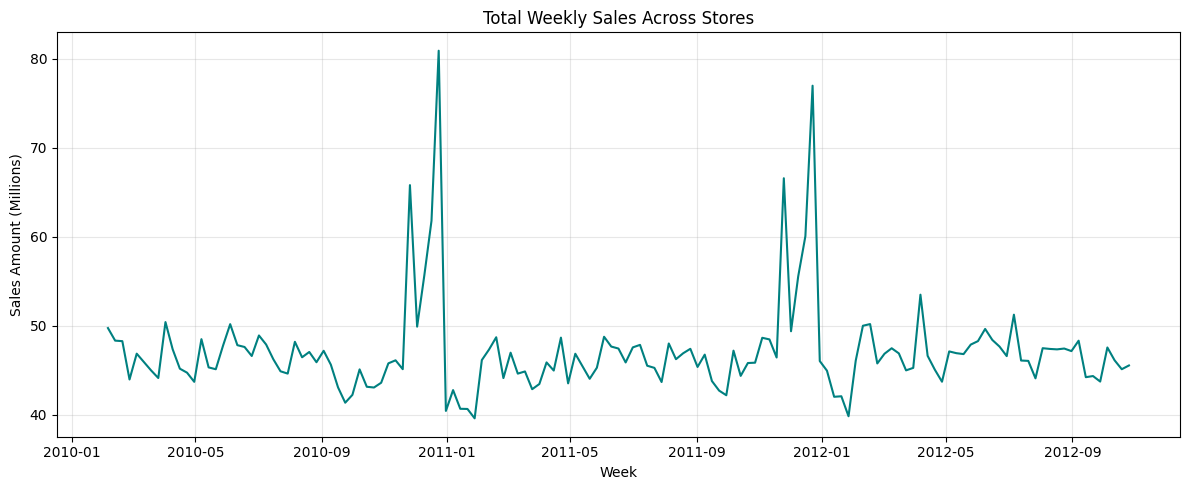

In [ ]:
import matplotlib.pyplot as plt

weekly_sales = (
    merged_data.groupby("Date")["Weekly_Sales"]
    .sum()
    .sort_index()
)

print("Number of observed weeks:", len(weekly_sales))

plt.figure(figsize=(12, 5))

plt.plot(
    weekly_sales.index,
    weekly_sales.values / 1_000_000,
    color="teal"
)

plt.title("Total Weekly Sales Across Stores")
plt.xlabel("Week")
plt.ylabel("Sales Amount (Millions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Top Stores by Total Observed Sales

We compare stores using their total sales over the available
historical period.

This identifies the largest sales contributors. Total sales
alone do not measure profitability or efficiency; store size
and observation coverage should also be considered.

Top 10 stores by total sales:
Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64


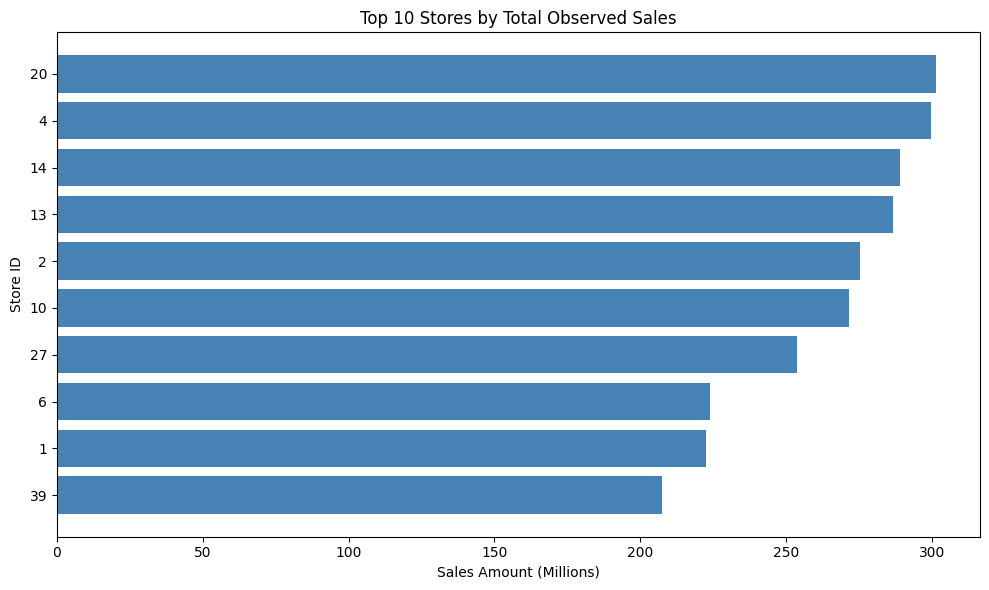

In [ ]:
store_sales = (
    merged_data.groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 stores by total sales:")
print(store_sales.head(10).round(2))

top_10 = store_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10.index.astype(str),
    top_10.values / 1_000_000,
    color="steelblue"
)

plt.title("Top 10 Stores by Total Observed Sales")
plt.xlabel("Sales Amount (Millions)")
plt.ylabel("Store ID")
plt.tight_layout()
plt.show()

## Holiday and Non-Holiday Sales Comparison

We compare mean and median sales per observed department-week
between holiday and non-holiday weeks.

This is a descriptive comparison. It does not prove that holidays
caused the difference, because seasonality and other factors
may also influence sales.

,Mean_Sales,Median_Sales,Records
IsHoliday,,,
False,15901.45,7589.95,391909
True,17035.82,7947.74,29661


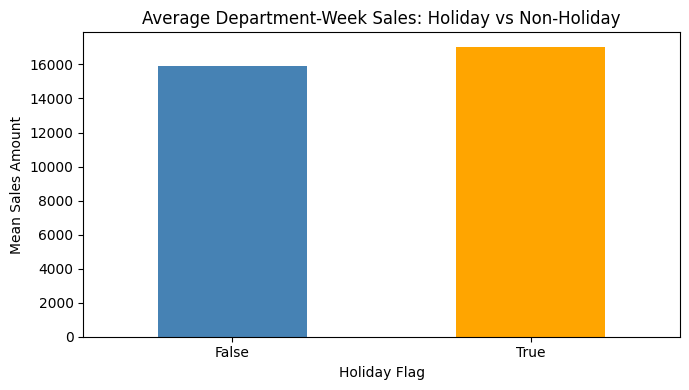

In [ ]:
holiday_summary = (
    merged_data.groupby("IsHoliday")["Weekly_Sales"]
    .agg(["mean", "median", "count"])
    .rename(columns={
        "mean": "Mean_Sales",
        "median": "Median_Sales",
        "count": "Records"
    })
)

display(holiday_summary.round(2))

holiday_summary["Mean_Sales"].plot(
    kind="bar",
    figsize=(7, 4),
    color=["steelblue", "orange"]
)

plt.title("Average Department-Week Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Flag")
plt.ylabel("Mean Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Monthly Sales Patterns

We compare average department-week sales by calendar month
across the available years.

Using averages avoids directly comparing monthly totals with
different numbers of observed weeks. However, differences in
year and department coverage may still affect the comparison.

,Weekly_Sales
Month,
1,14126.08
2,16008.78
3,15416.66
4,15650.34
5,15776.34
6,16326.14
7,15861.42
8,16062.52
9,15095.89


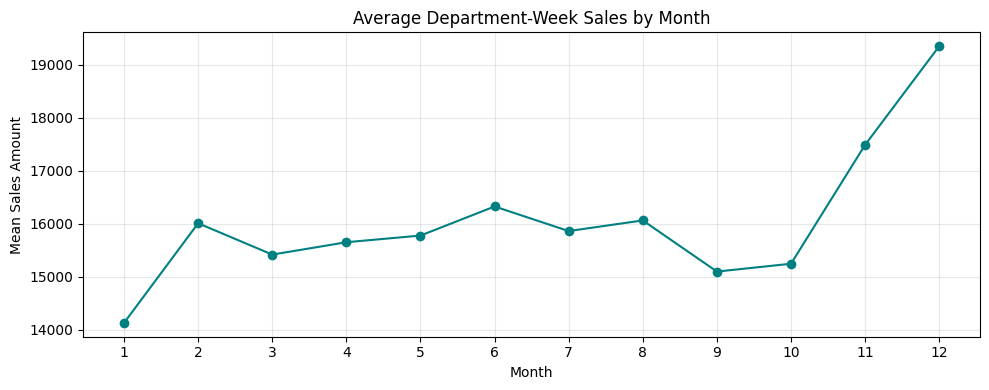

In [ ]:
monthly_sales = (
    merged_data.assign(
        Month=merged_data["Date"].dt.month
    )
    .groupby("Month")["Weekly_Sales"]
    .mean()
)

display(monthly_sales.round(2))

plt.figure(figsize=(10, 4))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    color="teal"
)

plt.title("Average Department-Week Sales by Month")
plt.xlabel("Month")
plt.ylabel("Mean Sales Amount")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sales Comparison by Store Type

We first calculate total sales for each store-week, then compare
the average store-week sales across store types.

This measures sales at the store level rather than treating each
department as a separate store observation. Differences in store
size and department coverage should be considered when interpreting
the results.

,Stores,Mean_Store_Weekly_Sales,Store_Weeks
Type,,,
A,22,1376673.47,3146
B,17,822994.96,2431
C,6,472614.83,858


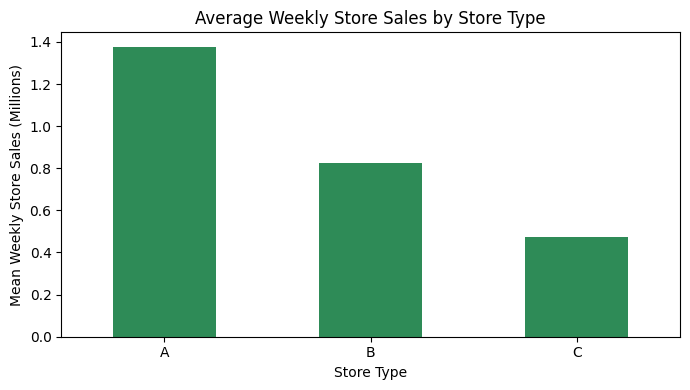

In [ ]:
store_week_sales = (
    merged_data.groupby(
        ["Store", "Type", "Date"],
        as_index=False
    )["Weekly_Sales"]
    .sum()
)

type_summary = (
    store_week_sales.groupby("Type")
    .agg(
        Stores=("Store", "nunique"),
        Mean_Store_Weekly_Sales=("Weekly_Sales", "mean"),
        Store_Weeks=("Weekly_Sales", "count")
    )
)

display(type_summary.round(2))

(type_summary["Mean_Store_Weekly_Sales"] / 1_000_000).plot(
    kind="bar",
    figsize=(7, 4),
    color="seagreen"
)

plt.title("Average Weekly Store Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Mean Weekly Store Sales (Millions)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Calendar Feature Engineering

We extract year, month, ISO week number, and quarter from Date.
These features can help models identify time-related sales patterns.

We keep the original Date column for chronological splitting
and time-series analysis.

In [ ]:
merged_data["Year"] = merged_data["Date"].dt.year
merged_data["Month"] = merged_data["Date"].dt.month
merged_data["WeekOfYear"] = (
    merged_data["Date"].dt.isocalendar().week.astype(int)
)
merged_data["Quarter"] = merged_data["Date"].dt.quarter

display(
    merged_data[
        ["Date", "Year", "Month", "WeekOfYear", "Quarter"]
    ].head()
)

,Date,Year,Month,WeekOfYear,Quarter
0,2010-02-05,2010,2,5,1
1,2010-02-12,2010,2,6,1
2,2010-02-19,2010,2,7,1
3,2010-02-26,2010,2,8,1
4,2010-03-05,2010,3,9,1


## Markdown Missingness Indicators

We create a binary indicator for each markdown column:
1 means the original value is missing, and 0 means it is available.

The original markdown values are preserved. Missing values are
not assumed to mean zero promotion. Any later imputation will
be fitted using training data only to avoid data leakage.

In [ ]:
markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

for column in markdown_columns:
    merged_data[column + "_Missing"] = (
        merged_data[column].isna().astype(int)
    )

display(
    merged_data[
        [
            "Date",
            "MarkDown1",
            "MarkDown1_Missing",
            "MarkDown2",
            "MarkDown2_Missing"
        ]
    ].head()
)

,Date,MarkDown1,MarkDown1_Missing,MarkDown2,MarkDown2_Missing
0,2010-02-05,NaN,1,NaN,1
1,2010-02-12,NaN,1,NaN,1
2,2010-02-19,NaN,1,NaN,1
3,2010-02-26,NaN,1,NaN,1
4,2010-03-05,NaN,1,NaN,1


## Saving a Prepared Data Checkpoint

We save the merged dataset with calendar features and markdown
missingness indicators to Google Drive.

This checkpoint preserves our progress without overwriting the
original CSV files. Missing values and negative sales remain
available for further investigation.

In [ ]:
output_folder = data_folder.parent / "outputs"
output_folder.mkdir(parents=True, exist_ok=True)

prepared_file = output_folder / "prepared_sales.csv.gz"

merged_data.to_csv(
    prepared_file,
    index=False,
    compression="gzip"
)

print("Prepared data shape:", merged_data.shape)
print("Saved successfully:", prepared_file.exists())
print("Saved at:", prepared_file)

Prepared data shape: (421570, 25)
Saved successfully: True
Saved at: /content/drive/MyDrive/Retail_Analytics_Project/outputs/prepared_sales.csv.gz


## Chronological Data Split

For one-week-ahead forecasting, we reserve the last 13 observed
weeks for testing and the preceding 13 weeks for validation.
Earlier observations form the training set.

Training data is used to learn patterns. Validation data helps
compare models. Test data is reserved for the final evaluation.
We do not randomly shuffle time-series observations.

Longer forecast horizons will require additional gaps between
training and evaluation periods to avoid future-data leakage.

In [ ]:
all_dates = sorted(merged_data["Date"].unique())

validation_start = pd.Timestamp(all_dates[-26])
test_start = pd.Timestamp(all_dates[-13])

train_data = merged_data[
    merged_data["Date"] < validation_start
].copy()

validation_data = merged_data[
    (merged_data["Date"] >= validation_start)
    & (merged_data["Date"] < test_start)
].copy()

test_data = merged_data[
    merged_data["Date"] >= test_start
].copy()

for name, dataset in [
    ("Training", train_data),
    ("Validation", validation_data),
    ("Test", test_data)
]:
    print(
        name,
        ":",
        dataset["Date"].min().date(),
        "to",
        dataset["Date"].max().date()
    )

Training : 2010-02-05 to 2012-04-27
Validation : 2012-05-04 to 2012-07-27
Test : 2012-08-03 to 2012-10-26


## One-Week-Ahead Naive Baseline

Our first forecasting baseline predicts that a department's
sales this week will equal its sales exactly seven days earlier.

We match records using Store, Dept, and Date. An exact date
match prevents missing weeks from being mistaken for consecutive
weeks. Missing historical observations remain unavailable.

In [ ]:
previous_week = merged_data[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].copy()

previous_week = previous_week.rename(
    columns={"Weekly_Sales": "Last_Week_Sales"}
)

previous_week["Date"] = (
    previous_week["Date"] + pd.Timedelta(days=7)
)

baseline_data = merged_data.merge(
    previous_week,
    on=["Store", "Dept", "Date"],
    how="left",
    validate="one_to_one"
)

display(
    baseline_data[
        ["Store", "Dept", "Date", "Weekly_Sales", "Last_Week_Sales"]
    ].head()
)

,Store,Dept,Date,Weekly_Sales,Last_Week_Sales
0,1,1,2010-02-05,24924.50,NaN
1,1,1,2010-02-12,46039.49,24924.50
2,1,1,2010-02-19,41595.55,46039.49
3,1,1,2010-02-26,19403.54,41595.55
4,1,1,2010-03-05,21827.90,19403.54


## Baseline Validation Performance

We evaluate the naive baseline using MAE, RMSE, and WAPE.
Only observations with available previous-week sales are scored.

This is rolling one-week-ahead evaluation: each prediction uses
the preceding week's observed sales. It is not a forecast of all
13 weeks made from one starting date. The test set remains unused.

In [ ]:
import numpy as np

baseline_validation = baseline_data[
    (baseline_data["Date"] >= validation_start)
    & (baseline_data["Date"] < test_start)
].copy()

scored_validation = baseline_validation.dropna(
    subset=["Last_Week_Sales"]
)

actual = scored_validation["Weekly_Sales"]
predicted = scored_validation["Last_Week_Sales"]

errors = actual - predicted

mae = errors.abs().mean()
rmse = np.sqrt((errors ** 2).mean())
wape = errors.abs().sum() / actual.abs().sum() * 100

print("Validation rows:", len(baseline_validation))
print("Rows evaluated:", len(scored_validation))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("WAPE (%):", round(wape, 2))

Validation rows: 38373
Rows evaluated: 37769
MAE: 1610.96
RMSE: 3490.17
WAPE (%): 9.86


## Seasonal Naive Baseline

Retail sales may repeat seasonal patterns. We create a baseline
using sales from exactly 52 weeks earlier for the same store
and department.

A 52-week lag means 364 days, not the same calendar date last year.
Some holidays may shift between weeks, so this baseline is approximate.

In [ ]:
previous_year = merged_data[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].copy()

previous_year = previous_year.rename(
    columns={"Weekly_Sales": "Sales_52_Weeks_Ago"}
)

previous_year["Date"] = (
    previous_year["Date"] + pd.Timedelta(weeks=52)
)

baseline_data = baseline_data.merge(
    previous_year,
    on=["Store", "Dept", "Date"],
    how="left",
    validate="one_to_one"
)

display(
    baseline_data[
        ["Store", "Dept", "Date", "Weekly_Sales", "Sales_52_Weeks_Ago"]
    ].head()
)

,Store,Dept,Date,Weekly_Sales,Sales_52_Weeks_Ago
0,1,1,2010-02-05,24924.50,NaN
1,1,1,2010-02-12,46039.49,NaN
2,1,1,2010-02-19,41595.55,NaN
3,1,1,2010-02-26,19403.54,NaN
4,1,1,2010-03-05,21827.90,NaN


## Comparing Forecasting Baselines

We compare the last-week and seasonal baselines on the same
validation observations.

If the 52-week historical value is unavailable, the seasonal
baseline falls back to last-week sales. We report how often
this fallback is used. Test data remains unused.

In [ ]:
comparison_data = baseline_data[
    (baseline_data["Date"] >= validation_start)
    & (baseline_data["Date"] < test_start)
    & baseline_data["Last_Week_Sales"].notna()
].copy()

fallback_count = comparison_data["Sales_52_Weeks_Ago"].isna().sum()

comparison_data["Seasonal_Prediction"] = (
    comparison_data["Sales_52_Weeks_Ago"]
    .fillna(comparison_data["Last_Week_Sales"])
)

results = []

for model_name, prediction_column in [
    ("Last-week baseline", "Last_Week_Sales"),
    ("Seasonal baseline", "Seasonal_Prediction")
]:
    actual = comparison_data["Weekly_Sales"]
    predicted = comparison_data[prediction_column]
    error = actual - predicted

    results.append({
        "Model": model_name,
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "WAPE_Percent": error.abs().sum() / actual.abs().sum() * 100
    })

baseline_results = pd.DataFrame(results)

print("Seasonal fallback records:", fallback_count)
display(baseline_results.round(2))

Seasonal fallback records: 744


,Model,MAE,RMSE,WAPE_Percent
0,Last-week baseline,1610.96,3490.17,9.86
1,Seasonal baseline,1749.76,3448.96,10.71


## Visual Comparison of Baseline Predictions

We plot weekly totals of actual sales and both baseline
predictions over the validation period, using the same scored rows.

This chart helps reveal overall tracking and missed peaks.
Aggregated errors can cancel out, so the chart does not replace
department-level error metrics.

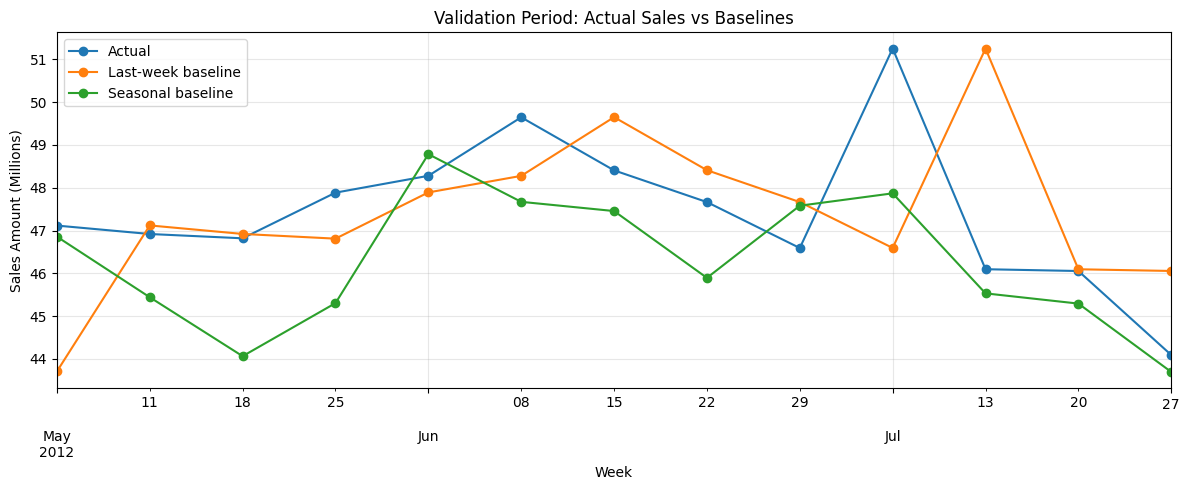

In [ ]:
weekly_comparison = (
    comparison_data.groupby("Date")[
        ["Weekly_Sales", "Last_Week_Sales", "Seasonal_Prediction"]
    ]
    .sum()
    .rename(columns={
        "Weekly_Sales": "Actual",
        "Last_Week_Sales": "Last-week baseline",
        "Seasonal_Prediction": "Seasonal baseline"
    })
)

(weekly_comparison / 1_000_000).plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Validation Period: Actual Sales vs Baselines")
plt.xlabel("Week")
plt.ylabel("Sales Amount (Millions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Anomaly Detection: Weekly Sales Changes

We calculate the difference between current sales and sales
exactly one week earlier for each store-department combination.

Large changes may indicate unusual activity, holiday effects,
promotions, returns, or data issues. They require investigation
rather than automatic removal.

In [ ]:
baseline_data["Sales_Change"] = (
    baseline_data["Weekly_Sales"]
    - baseline_data["Last_Week_Sales"]
)

display(
    baseline_data[
        [
            "Store", "Dept", "Date",
            "Weekly_Sales", "Last_Week_Sales", "Sales_Change"
        ]
    ].head()
)

,Store,Dept,Date,Weekly_Sales,Last_Week_Sales,Sales_Change
0,1,1,2010-02-05,24924.50,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,21114.99
2,1,1,2010-02-19,41595.55,46039.49,-4443.94
3,1,1,2010-02-26,19403.54,41595.55,-22192.01
4,1,1,2010-03-05,21827.90,19403.54,2424.36


## Learning Typical Sales Changes

For each store-department series, we calculate the median sales
change and its Median Absolute Deviation (MAD) using training
dates only.

MAD measures variation around the median and is less sensitive
to extreme values than standard deviation. Series with fewer
than 20 valid changes or zero MAD will remain unscored.

In [ ]:
anomaly_training = baseline_data[
    baseline_data["Date"] < validation_start
].copy()

change_stats = (
    anomaly_training.groupby(["Store", "Dept"])["Sales_Change"]
    .agg(
        Valid_Changes="count",
        Median_Change="median",
        MAD=lambda values: (
            values - values.median()
        ).abs().median()
    )
    .reset_index()
)

display(change_stats.head())

,Store,Dept,Valid_Changes,Median_Change,MAD
0,1,1,116,428.835,1533.480
1,1,2,116,40.990,2241.665
2,1,3,116,150.040,940.165
3,1,4,116,-303.630,2048.130
4,1,5,116,-665.810,2484.295


## Flagging Unusual Sales Changes

We calculate a robust score using the training median and MAD.
A scale factor of 1.4826 makes MAD comparable to standard
deviation under a normal-distribution assumption.

An absolute score above 5 is flagged for review. This threshold
is an initial analytical choice, not a validated accuracy measure.
Unscorable records remain separate, and no sales rows are deleted.
Training-period flags are retrospective; later flags use frozen
training statistics.

In [ ]:
anomaly_data = baseline_data.merge(
    change_stats,
    on=["Store", "Dept"],
    how="left",
    validate="many_to_one"
)

usable_history = (
    (anomaly_data["Valid_Changes"] >= 20)
    & (anomaly_data["MAD"] > 0)
)

scale = (1.4826 * anomaly_data["MAD"]).where(usable_history)

anomaly_data["Anomaly_Score"] = (
    (
        anomaly_data["Sales_Change"]
        - anomaly_data["Median_Change"]
    ).abs()
    / scale
)

anomaly_data["Anomaly_Status"] = np.where(
    anomaly_data["Anomaly_Score"].isna(),
    "Not scored",
    np.where(
        anomaly_data["Anomaly_Score"] > 5,
        "Review",
        "Within threshold"
    )
)

print(anomaly_data["Anomaly_Status"].value_counts())

display(
    anomaly_data[
        anomaly_data["Anomaly_Status"] == "Review"
    ].nlargest(10, "Anomaly_Score")[
        [
            "Store", "Dept", "Date", "Weekly_Sales",
            "Sales_Change", "IsHoliday", "Anomaly_Score"
        ]
    ]
)

Anomaly_Status
Within threshold    400635
Not scored           10695
Review               10240
Name: count, dtype: int64


,Store,Dept,Date,Weekly_Sales,Sales_Change,IsHoliday,Anomaly_Score
337401,35,59,2010-12-31,5855.31,-20276.97,True,167.728622
36634,4,59,2010-12-31,11310.17,-28411.40,True,164.491864
174282,18,59,2010-12-31,4380.51,-19598.52,True,163.771030
226271,23,94,2011-02-25,0.88,-3548.62,False,140.730653
94806,10,59,2010-12-24,49196.79,25065.38,False,122.690873
114654,12,59,2010-12-24,26504.68,16822.86,False,116.755455
104802,11,59,2010-12-31,7194.48,-18441.77,True,115.814507
226270,23,94,2011-02-18,3549.50,2853.58,False,113.133235
135097,14,59,2010-12-24,30901.24,18823.77,False,107.499264
204299,21,59,2010-12-31,4315.94,-9864.29,True,107.049995


## Investigating Anomalies Around Holidays

We compare the percentage of scored records flagged for review
during holiday and non-holiday weeks.

Rates are more informative than raw counts because the two
groups contain different numbers of observations. A higher rate
does not prove that holidays caused the anomalies.

In [ ]:
scored_anomalies = anomaly_data[
    anomaly_data["Anomaly_Status"] != "Not scored"
].copy()

scored_anomalies["Flagged"] = (
    scored_anomalies["Anomaly_Status"] == "Review"
)

holiday_anomalies = (
    scored_anomalies.groupby("IsHoliday")
    .agg(
        Scored_Records=("Flagged", "size"),
        Flagged_Records=("Flagged", "sum"),
        Flag_Rate_Percent=("Flagged", lambda values: values.mean() * 100)
    )
)

display(holiday_anomalies.round(2))

,Scored_Records,Flagged_Records,Flag_Rate_Percent
IsHoliday,,,
False,381850,6687,1.75
True,29025,3553,12.24


## Visual Review of Sales Anomalies

We plot sales for Store 1, Department 1 and highlight records
flagged by the weekly-change detector.

The chart supports contextual review. A flagged point may be
a genuine seasonal peak or a sharp decline after a peak.
The detector measures changes, not just unusually high sales.

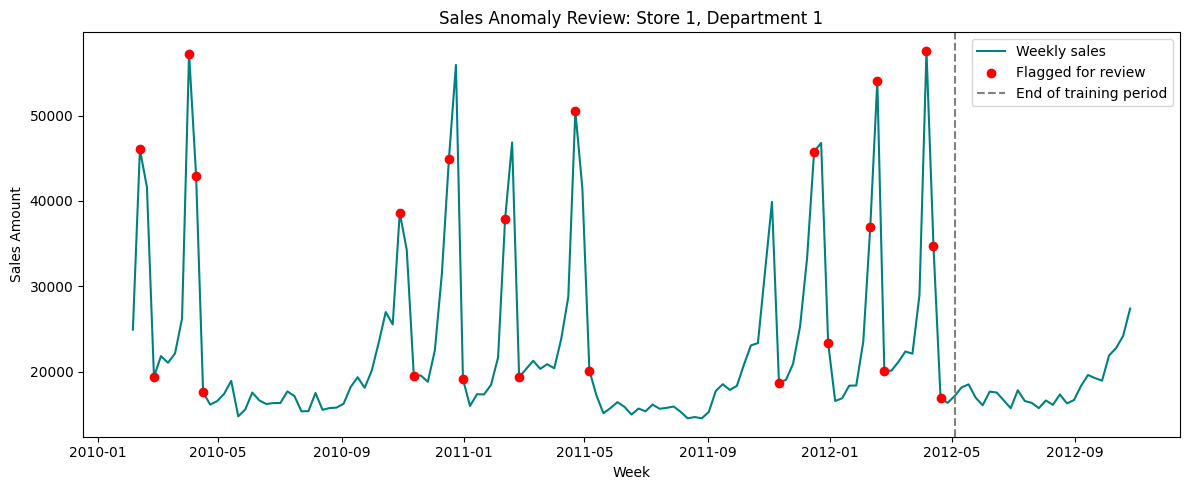

Flagged observations in this series: 22


In [ ]:
example_series = anomaly_data[
    (anomaly_data["Store"] == 1)
    & (anomaly_data["Dept"] == 1)
].sort_values("Date")

flagged_points = example_series[
    example_series["Anomaly_Status"] == "Review"
]

plt.figure(figsize=(12, 5))

plt.plot(
    example_series["Date"],
    example_series["Weekly_Sales"],
    label="Weekly sales",
    color="teal"
)

plt.scatter(
    flagged_points["Date"],
    flagged_points["Weekly_Sales"],
    color="red",
    label="Flagged for review",
    zorder=3
)

plt.axvline(
    validation_start,
    color="grey",
    linestyle="--",
    label="End of training period"
)

plt.title("Sales Anomaly Review: Store 1, Department 1")
plt.xlabel("Week")
plt.ylabel("Sales Amount")
plt.legend()
plt.tight_layout()
plt.show()

print("Flagged observations in this series:", len(flagged_points))

## Anomaly Threshold Sensitivity

We compare thresholds of 4, 5, and 6 on the same scored
validation observations while keeping training statistics fixed.

A lower threshold generally produces more alerts. This analysis
helps assess review workload, but verified labels are needed
to measure detection precision and recall. Test data is not
used to select the threshold.

In [ ]:
validation_scores = anomaly_data.loc[
    (anomaly_data["Date"] >= validation_start)
    & (anomaly_data["Date"] < test_start),
    "Anomaly_Score"
].dropna()

sensitivity_results = []

for threshold in [4, 5, 6]:
    flagged = validation_scores > threshold

    sensitivity_results.append({
        "Threshold": threshold,
        "Scored_Records": len(validation_scores),
        "Flagged_Records": int(flagged.sum()),
        "Flag_Rate_Percent": flagged.mean() * 100
    })

sensitivity_table = pd.DataFrame(sensitivity_results)

display(sensitivity_table.round(2))

,Threshold,Scored_Records,Flagged_Records,Flag_Rate_Percent
0,4,37475,692,1.85
1,5,37475,453,1.21
2,6,37475,332,0.89


## Preparing Inputs for Isolation Forest

Isolation Forest identifies observations with unusual combinations
of sales, sales changes, store size, and external factors.

We learn missing-value replacements from training data only and
apply the same replacements to validation data. Original data
remains unchanged.

This is anomaly detection after sales are observed, not forecasting.
Current-week sales are therefore valid inputs here.

In [ ]:
anomaly_features = [
    "Weekly_Sales",
    "Sales_Change",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Size"
]

iso_train = anomaly_data[
    anomaly_data["Date"] < validation_start
].copy()

iso_validation = anomaly_data[
    (anomaly_data["Date"] >= validation_start)
    & (anomaly_data["Date"] < test_start)
].copy()

training_medians = iso_train[anomaly_features].median()

X_anomaly_train = (
    iso_train[anomaly_features].fillna(training_medians)
)

X_anomaly_validation = (
    iso_validation[anomaly_features].fillna(training_medians)
)

print(
    "Missing training inputs:",
    X_anomaly_train.isna().sum().sum()
)

print(
    "Missing validation inputs:",
    X_anomaly_validation.isna().sum().sum()
)

Missing training inputs: 0
Missing validation inputs: 0


## Isolation Forest Anomaly Detection

We train an Isolation Forest on historical training observations
and apply it to validation observations.

The contamination setting of 0.01 sets the threshold using an
assumed training anomaly proportion of approximately 1%.
It is an analytical choice, not measured accuracy, and does not
force the validation anomaly rate to equal 1%.

In [ ]:
from sklearn.ensemble import IsolationForest

isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=2
)

isolation_model.fit(X_anomaly_train)

iso_validation["Isolation_Flag"] = (
    isolation_model.predict(X_anomaly_validation) == -1
)

iso_validation["Isolation_Score"] = (
    -isolation_model.score_samples(X_anomaly_validation)
)

print(
    "Validation records:",
    len(iso_validation)
)

print(
    "Isolation Forest flags:",
    iso_validation["Isolation_Flag"].sum()
)

print(
    "Validation flag rate (%):",
    round(iso_validation["Isolation_Flag"].mean() * 100, 2)
)

Validation records: 38373
Isolation Forest flags: 358
Validation flag rate (%): 0.93


## Comparing Anomaly Detection Methods

We compare Isolation Forest flags with the earlier robust
weekly-change flags on validation records that both methods
can score.

Agreement identifies cases for joint review. Disagreement is
expected because the methods examine different patterns.
Neither method is treated as ground truth.

In [ ]:
comparison_anomalies = iso_validation[
    iso_validation["Anomaly_Status"] != "Not scored"
].copy()

comparison_anomalies["Robust_Flag"] = (
    comparison_anomalies["Anomaly_Status"] == "Review"
)

agreement_table = pd.crosstab(
    comparison_anomalies["Robust_Flag"],
    comparison_anomalies["Isolation_Flag"],
    rownames=["Robust method flagged"],
    colnames=["Isolation Forest flagged"]
).reindex(
    index=[False, True],
    columns=[False, True],
    fill_value=0
)

display(agreement_table)

display(
    iso_validation.nlargest(10, "Isolation_Score")[
        [
            "Store",
            "Dept",
            "Date",
            "Weekly_Sales",
            "IsHoliday",
            "Anomaly_Status",
            "Isolation_Flag",
            "Isolation_Score"
        ]
    ]
)

Isolation Forest flagged,False,True
Robust method flagged,,
False,36673,349
True,444,9


,Store,Dept,Date,Weekly_Sales,IsHoliday,Anomaly_Status,Isolation_Flag,Isolation_Score
357321,38,38,2012-05-11,70615.63,False,Within threshold,True,0.673004
276169,28,92,2012-05-11,92860.95,False,Within threshold,True,0.667156
276177,28,92,2012-07-06,147221.14,False,Within threshold,True,0.665778
276168,28,92,2012-05-04,132410.24,False,Within threshold,True,0.662784
276174,28,92,2012-06-15,85535.59,False,Within threshold,True,0.659829
397131,42,92,2012-05-18,83776.62,False,Within threshold,True,0.658666
357327,38,38,2012-06-22,70600.60,False,Within threshold,True,0.655366
397134,42,92,2012-06-08,102091.86,False,Within threshold,True,0.654751
357320,38,38,2012-05-04,91894.49,False,Within threshold,True,0.654616
357323,38,38,2012-05-25,74590.30,False,Within threshold,True,0.654185


## Store Segmentation: Preparing Weekly Store Sales

We aggregate department sales into total sales for each store
and week, using training dates only.

This gives each store-week one observation and avoids treating
individual departments as separate stores.

In [ ]:
segmentation_weekly = (
    train_data.groupby(
        ["Store", "Date"],
        as_index=False
    )
    .agg(
        Store_Weekly_Sales=("Weekly_Sales", "sum"),
        IsHoliday=("IsHoliday", "first")
    )
)

print("Number of stores:", segmentation_weekly["Store"].nunique())

display(segmentation_weekly.head())

Number of stores: 45


,Store,Date,Store_Weekly_Sales,IsHoliday
0,1,2010-02-05,1643690.90,False
1,1,2010-02-12,1641957.44,True
2,1,2010-02-19,1611968.17,False
3,1,2010-02-26,1409727.59,False
4,1,2010-03-05,1554806.68,False


## Creating Store Profiles

For each store, we calculate average weekly sales, sales
variability, and the ratio of holiday to non-holiday average sales.

We also add store size. These features describe sales level,
stability, holiday patterns, and store scale. Holiday ratios
are descriptive associations, not causal effects.

In [ ]:
store_profiles = (
    segmentation_weekly.groupby("Store")
    .agg(
        Mean_Weekly_Sales=("Store_Weekly_Sales", "mean"),
        Std_Weekly_Sales=("Store_Weekly_Sales", "std"),
        Observed_Weeks=("Store_Weekly_Sales", "count")
    )
    .reset_index()
)

store_profiles["Sales_CV"] = (
    store_profiles["Std_Weekly_Sales"]
    / store_profiles["Mean_Weekly_Sales"].abs().replace(0, np.nan)
)

holiday_means = (
    segmentation_weekly.groupby(
        ["Store", "IsHoliday"]
    )["Store_Weekly_Sales"]
    .mean()
    .unstack("IsHoliday")
)

holiday_ratio = (
    holiday_means[True]
    / holiday_means[False].replace(0, np.nan)
)

store_profiles["Holiday_Ratio"] = (
    store_profiles["Store"].map(holiday_ratio)
)

store_profiles = store_profiles.merge(
    stores,
    on="Store",
    how="left",
    validate="one_to_one"
)

print("Store profile rows:", len(store_profiles))
display(store_profiles.head().round(2))

Store profile rows: 45


,Store,Mean_Weekly_Sales,Std_Weekly_Sales,Observed_Weeks,Sales_CV,Holiday_Ratio,Type,Size
0,1,1550732.72,167987.91,117,0.11,1.08,A,151315
1,2,1932396.14,260227.98,117,0.13,1.09,A,202307
2,3,399466.37,50111.56,117,0.13,1.11,B,37392
3,4,2081085.34,291391.69,117,0.14,1.09,A,205863
4,5,315845.74,40709.51,117,0.13,1.15,B,34875


## Scaling Store Segmentation Features

We standardize the numerical features before clustering.
Sales and size have much larger numerical values than ratios,
which could otherwise dominate distance calculations.

StandardScaler centers each feature around zero and scales it
to unit variance. Store IDs are excluded because they are
identifiers, not numerical measures of similarity.

In [ ]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "Mean_Weekly_Sales",
    "Sales_CV",
    "Holiday_Ratio",
    "Size"
]

cluster_inputs = store_profiles[cluster_features].copy()

print("Missing clustering inputs:")
print(cluster_inputs.isna().sum())

assert np.isfinite(cluster_inputs.to_numpy()).all(), (
    "Missing or infinite values found. Investigate before clustering."
)

cluster_scaler = StandardScaler()

scaled_store_features = cluster_scaler.fit_transform(
    cluster_inputs
)

scaled_preview = pd.DataFrame(
    scaled_store_features,
    columns=cluster_features,
    index=store_profiles["Store"]
)

display(scaled_preview.head().round(2))

Missing clustering inputs:
Mean_Weekly_Sales    0
Sales_CV             0
Holiday_Ratio        0
Size                 0
dtype: int64


,Mean_Weekly_Sales,Sales_CV,Holiday_Ratio,Size
Store,,,,
1,0.92,-0.80,0.04,0.33
2,1.63,-0.15,0.28,1.14
3,-1.19,-0.37,0.64,-1.47
4,1.90,-0.01,0.23,1.20
5,-1.35,-0.29,1.39,-1.51


## Selecting the Number of Store Segments

We compare K-Means solutions with two to six clusters using
the standardized store profiles.

Higher silhouette scores and lower Davies–Bouldin scores
generally indicate better separation. We also examine cluster
sizes because very small groups may be unstable or difficult
to use in business decisions.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

cluster_models = {}
cluster_results = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = model.fit_predict(scaled_store_features)

    cluster_models[k] = model

    cluster_results.append({
        "Clusters": k,
        "Silhouette": silhouette_score(
            scaled_store_features, labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            scaled_store_features, labels
        ),
        "Smallest_Cluster": pd.Series(labels).value_counts().min()
    })

cluster_quality = pd.DataFrame(cluster_results)

display(cluster_quality.round(3))

,Clusters,Silhouette,Davies_Bouldin,Smallest_Cluster
0,2,0.457,0.822,10
1,3,0.448,0.847,8
2,4,0.388,0.967,8
3,5,0.412,0.836,3
4,6,0.379,0.878,3


## Assigning Store Segments

For this initial analysis, we select the candidate with the
highest silhouette score and assign its cluster labels to stores.

Cluster numbers are arbitrary identifiers, not performance
rankings. The selected grouping still requires business
interpretation and stability checks.

In [ ]:
best_k = int(
    cluster_quality.sort_values(
        "Silhouette", ascending=False
    ).iloc[0]["Clusters"]
)

best_cluster_model = cluster_models[best_k]

store_profiles["Segment"] = best_cluster_model.labels_

print("Selected number of segments:", best_k)

print("\nStores in each segment:")
print(
    store_profiles["Segment"]
    .value_counts()
    .sort_index()
)

display(
    store_profiles[
        ["Store", "Type", "Size", "Mean_Weekly_Sales", "Segment"]
    ].head(10)
)

Selected number of segments: 2

Stores in each segment:
Segment
0    35
1    10
Name: count, dtype: int64


,Store,Type,Size,Mean_Weekly_Sales,Segment
0,1,A,151315,1.550733e+06,0
1,2,A,202307,1.932396e+06,0
2,3,B,37392,3.994664e+05,1
3,4,A,205863,2.081085e+06,0
4,5,B,34875,3.158457e+05,1
5,6,A,202505,1.566477e+06,0
6,7,B,70713,5.648494e+05,0
7,8,A,155078,9.085061e+05,0
8,9,B,125833,5.416652e+05,0
9,10,B,126512,1.927404e+06,0


## Interpreting Store Segments

We summarize each segment using original, unscaled values:
average weekly sales, relative sales variability, holiday ratio,
and store size.

These summaries help describe the groups in business terms.
Segment names and recommendations should follow the observed
profiles rather than being assumed in advance.

In [ ]:
segment_summary = (
    store_profiles.groupby("Segment")
    .agg(
        Stores=("Store", "count"),
        Mean_Weekly_Sales=("Mean_Weekly_Sales", "mean"),
        Mean_Sales_CV=("Sales_CV", "mean"),
        Mean_Holiday_Ratio=("Holiday_Ratio", "mean"),
        Mean_Size=("Size", "mean")
    )
)

display(segment_summary.round(2))

print("\nStore types within each segment:")

display(
    pd.crosstab(
        store_profiles["Segment"],
        store_profiles["Type"]
    )
)

,Stores,Mean_Weekly_Sales,Mean_Sales_CV,Mean_Holiday_Ratio,Mean_Size
Segment,,,,,
0,35,1228139.10,0.15,1.10,156223.57
1,10,418158.21,0.09,1.02,39511.70



Store types within each segment:


Type,A,B,C
Segment,,,
0,20,15,0
1,2,2,6


## Store Segment Findings

The two-cluster solution achieved a silhouette score of 0.457
and a Davies–Bouldin score of 0.822.

Segment 0 contains 35 stores with higher average weekly sales
and larger average size. Its average holiday/non-holiday sales
ratio is approximately 1.10.

Segment 1 contains 10 stores with lower average weekly sales,
smaller average size, and lower relative sales variability.
Its average holiday ratio is approximately 1.02.

These are group averages, not characteristics shared equally
by every store. Lower total sales do not establish poorer
performance. The three-cluster solution has a similar silhouette
score and remains a reasonable alternative for further review.

In [ ]:
segment_names = {
    0: "Larger stores, higher sales",
    1: "Smaller stores, lower variability"
}

store_profiles["Segment_Name"] = (
    store_profiles["Segment"].map(segment_names)
)

display(
    store_profiles[
        ["Store", "Type", "Segment", "Segment_Name"]
    ].head(10)
)

,Store,Type,Segment,Segment_Name
0,1,A,0,"Larger stores, higher sales"
1,2,A,0,"Larger stores, higher sales"
2,3,B,1,"Smaller stores, lower variability"
3,4,A,0,"Larger stores, higher sales"
4,5,B,1,"Smaller stores, lower variability"
5,6,A,0,"Larger stores, higher sales"
6,7,B,0,"Larger stores, higher sales"
7,8,A,0,"Larger stores, higher sales"
8,9,B,0,"Larger stores, higher sales"
9,10,B,0,"Larger stores, higher sales"


## Visualizing Store Segments

We visualize stores using average weekly sales and relative
sales variability, with colors indicating segment membership.

Clustering used four features, while this chart shows only two.
The plot therefore provides a partial view of the segmentation.

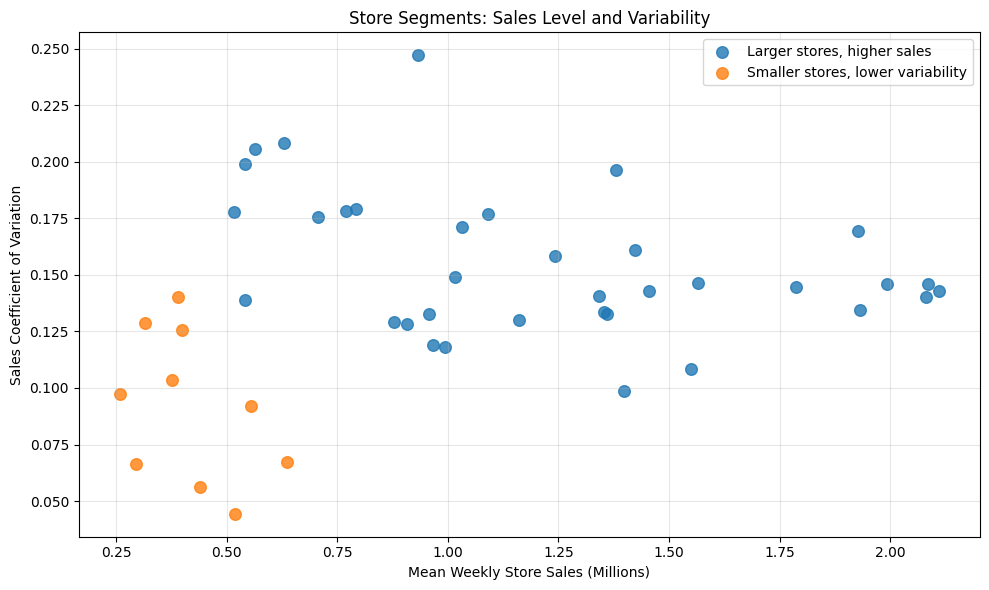

In [ ]:
plt.figure(figsize=(10, 6))

for segment, group in store_profiles.groupby("Segment"):
    plt.scatter(
        group["Mean_Weekly_Sales"] / 1_000_000,
        group["Sales_CV"],
        label=segment_names[segment],
        s=70,
        alpha=0.8
    )

plt.title("Store Segments: Sales Level and Variability")
plt.xlabel("Mean Weekly Store Sales (Millions)")
plt.ylabel("Sales Coefficient of Variation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_folder / "store_segments.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Saving Segmentation Results

We save store assignments, segment summaries, and clustering
quality metrics for reporting and later business analysis.

These files preserve the current segmentation results.

In [ ]:
store_profiles.to_csv(
    output_folder / "store_segments.csv",
    index=False
)

segment_summary.reset_index().to_csv(
    output_folder / "segment_summary.csv",
    index=False
)

cluster_quality.to_csv(
    output_folder / "cluster_quality.csv",
    index=False
)

print("Saved: store_segments.csv")
print("Saved: segment_summary.csv")
print("Saved: cluster_quality.csv")
print("Saved chart: store_segments.png")

Saved: store_segments.csv
Saved: segment_summary.csv
Saved: cluster_quality.csv
Saved chart: store_segments.png


## Preparing Store-Level Context Features

We use one record per store-week to summarize markdowns and
external factors during the training period.

This avoids counting the same store-week information repeatedly
across departments. Missing markdowns remain unknown and are
not replaced with zero.

In [ ]:
context_columns = [
    "Store", "Date",
    "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "MarkDown1", "MarkDown2", "MarkDown3",
    "MarkDown4", "MarkDown5"
]

store_week_context = (
    train_data[context_columns]
    .drop_duplicates(subset=["Store", "Date"])
    .copy()
)

store_week_context["Markdown_Availability"] = (
    store_week_context[markdown_columns]
    .notna()
    .mean(axis=1)
)

print("Stores:", store_week_context["Store"].nunique())

print(
    "Repeated store-week keys:",
    store_week_context.duplicated(["Store", "Date"]).sum()
)

display(store_week_context.head())

Stores: 45
Repeated store-week keys: 0


,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Markdown_Availability
0,1,2010-02-05,42.31,2.572,211.096358,8.106,NaN,NaN,NaN,NaN,NaN,0.0
1,1,2010-02-12,38.51,2.548,211.242170,8.106,NaN,NaN,NaN,NaN,NaN,0.0
2,1,2010-02-19,39.93,2.514,211.289143,8.106,NaN,NaN,NaN,NaN,NaN,0.0
3,1,2010-02-26,46.63,2.561,211.319643,8.106,NaN,NaN,NaN,NaN,NaN,0.0
4,1,2010-03-05,46.50,2.625,211.350143,8.106,NaN,NaN,NaN,NaN,NaN,0.0


## Summarizing External Factors by Store

We calculate each store's average external indicators and
markdown data availability during training.

Markdown means use only recorded values. They should not be
interpreted as average spending across all weeks, because
missing observations are excluded.

In [ ]:
store_context = (
    store_week_context.groupby("Store")
    .agg(
        Mean_Temperature=("Temperature", "mean"),
        Mean_Fuel_Price=("Fuel_Price", "mean"),
        Mean_CPI=("CPI", "mean"),
        Mean_Unemployment=("Unemployment", "mean"),
        Markdown_Availability=("Markdown_Availability", "mean"),
        Mean_Recorded_MarkDown1=("MarkDown1", "mean")
    )
    .reset_index()
)

store_context = store_context.merge(
    store_profiles[["Store", "Segment", "Segment_Name"]],
    on="Store",
    how="left",
    validate="one_to_one"
)

assert store_context["Segment"].notna().all()

display(store_context.head().round(2))

,Store,Mean_Temperature,Mean_Fuel_Price,Mean_CPI,Mean_Unemployment,Markdown_Availability,Mean_Recorded_MarkDown1,Segment,Segment_Name
0,1,66.35,3.15,214.61,7.76,0.21,7735.41,0,"Larger stores, higher sales"
1,2,65.89,3.15,214.26,7.85,0.21,11274.53,0,"Larger stores, higher sales"
2,3,69.47,3.15,217.98,7.35,0.20,3391.72,1,"Smaller stores, lower variability"
3,4,59.39,3.15,128.18,6.37,0.21,8738.74,0,"Larger stores, higher sales"
4,5,67.28,3.15,215.17,6.44,0.20,3272.70,1,"Smaller stores, lower variability"


## Comparing Segment Context

We compare average store-level external indicators and markdown
availability across the existing segments. Each store receives
equal weight in these segment averages.

These differences are descriptive. They do not establish regional
identities, promotion responsiveness, or causal economic effects.
Store locations and customer-level data are unavailable.

In [ ]:
segment_context = (
    store_context.groupby("Segment_Name")
    .agg(
        Stores=("Store", "count"),
        Mean_Temperature=("Mean_Temperature", "mean"),
        Mean_Fuel_Price=("Mean_Fuel_Price", "mean"),
        Mean_CPI=("Mean_CPI", "mean"),
        Mean_Unemployment=("Mean_Unemployment", "mean"),
        Markdown_Availability=("Markdown_Availability", "mean"),
        Mean_Recorded_MarkDown1=("Mean_Recorded_MarkDown1", "mean")
    )
)

segment_context["Markdown_Availability_Percent"] = (
    segment_context.pop("Markdown_Availability") * 100
)

display(segment_context.round(2))

segment_context.reset_index().to_csv(
    output_folder / "segment_context.csv",
    index=False
)

print("Saved: segment_context.csv")

,Stores,Mean_Temperature,Mean_Fuel_Price,Mean_CPI,Mean_Unemployment,Mean_Recorded_MarkDown1,Markdown_Availability_Percent
Segment_Name,,,,,,,
"Larger stores, higher sales",35,55.44,3.28,168.13,8.04,8647.98,20.82
"Smaller stores, lower variability",10,66.93,3.25,179.33,8.60,980.51,16.22


Saved: segment_context.csv


## Department Association Analysis: Defining Sales Events

Actual transaction baskets are unavailable. We therefore explore
department-level sales events as a limited proxy.

A strong-sales event occurs when sales exceed the same department's
sales 52 weeks earlier by more than 20%. We use non-holiday training
weeks with a positive seasonal reference.

The threshold is an analytical choice. Shared trends and promotions
may still influence the associations.

In [ ]:
association_data = baseline_data[
    (baseline_data["Date"] < validation_start)
    & (~baseline_data["IsHoliday"])
    & (baseline_data["Sales_52_Weeks_Ago"] > 0)
].copy()

association_data["Strong_Sales_Event"] = (
    association_data["Weekly_Sales"]
    > 1.20 * association_data["Sales_52_Weeks_Ago"]
).astype(int)

display(
    association_data[
        [
            "Store", "Dept", "Date",
            "Weekly_Sales", "Sales_52_Weeks_Ago",
            "Strong_Sales_Event"
        ]
    ].head()
)

print("Eligible department-week records:", len(association_data))

,Store,Dept,Date,Weekly_Sales,Sales_52_Weeks_Ago,Strong_Sales_Event
52,1,1,2011-02-04,21665.76,24924.50,0
54,1,1,2011-02-18,46845.87,41595.55,0
55,1,1,2011-02-25,19363.83,19403.54,0
56,1,1,2011-03-04,20327.61,21827.90,0
57,1,1,2011-03-11,21280.40,21043.39,0


Eligible department-week records: 171961


## Building the Department Event Matrix

We create a matrix with one row per store-week and one column
per department.

A value of 1 indicates a strong-sales event, and 0 indicates an
eligible observation without that event. Missing values represent
unavailable or ineligible observations and are not filled with zero.

In [ ]:
event_matrix = association_data.pivot(
    index=["Store", "Date"],
    columns="Dept",
    values="Strong_Sales_Event"
)

print("Event matrix shape:", event_matrix.shape)

display(event_matrix.iloc[:5, :8])

Event matrix shape: (2700, 78)


Dept                1    2    3    4    5    6    7    8
Store Date                                              
1     2011-02-04  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
      2011-02-18  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
      2011-02-25  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
      2011-03-04  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
      2011-03-11  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

## Calculating Department Association Rules

For each department pair, we calculate rules in both directions.
We require at least 200 jointly observed store-weeks and at least
20 joint strong-sales events.

Support measures joint-event frequency. Confidence measures the
frequency of the consequent event when the antecedent event occurs.
Lift compares confidence with the consequent's baseline event rate.

These thresholds are exploratory screening choices. Pairwise
coverage differs, and high lift alone does not establish a reliable
cross-selling opportunity.

In [ ]:
from itertools import combinations

rules = []

for dept_a, dept_b in combinations(event_matrix.columns, 2):
    pair = event_matrix[[dept_a, dept_b]].dropna()

    n = len(pair)

    if n < 200:
        continue

    count_a = int(pair[dept_a].sum())
    count_b = int(pair[dept_b].sum())

    joint_count = int(
        ((pair[dept_a] == 1) & (pair[dept_b] == 1)).sum()
    )

    if joint_count < 20:
        continue

    for source, target, source_count, target_count in [
        (dept_a, dept_b, count_a, count_b),
        (dept_b, dept_a, count_b, count_a)
    ]:
        support = joint_count / n
        confidence = joint_count / source_count
        lift = confidence / (target_count / n)

        rules.append({
            "From_Dept": source,
            "To_Dept": target,
            "Eligible_Weeks": n,
            "Joint_Events": joint_count,
            "Support": support,
            "Confidence": confidence,
            "Lift": lift
        })

association_rules = pd.DataFrame(
    rules,
    columns=[
        "From_Dept", "To_Dept", "Eligible_Weeks",
        "Joint_Events", "Support", "Confidence", "Lift"
    ]
).sort_values(
    ["Lift", "Joint_Events"],
    ascending=False
)

print("Rules found:", len(association_rules))

display(association_rules.head(10).round(3))

association_rules.to_csv(
    output_folder / "department_association_rules.csv",
    index=False
)

Rules found: 4376


,From_Dept,To_Dept,Eligible_Weeks,Joint_Events,Support,Confidence,Lift
754,8,40,2700,21,0.008,0.300,20.769
755,40,8,2700,21,0.008,0.538,20.769
360,4,95,2700,27,0.010,0.500,7.941
361,95,4,2700,27,0.010,0.159,7.941
4330,91,97,2618,180,0.069,0.729,6.115
4331,97,91,2618,180,0.069,0.577,6.115
4366,95,97,2618,92,0.035,0.713,5.984
4367,97,95,2618,92,0.035,0.295,5.984
174,2,46,2700,23,0.009,0.359,5.953
175,46,2,2700,23,0.009,0.141,5.953


## Validating Department Associations

We apply the same strong-sales definition to non-holiday
validation weeks: sales more than 20% above the 52-week reference.

The event definition remains unchanged. We use validation data
to assess whether training associations persist in later weeks.
Test data remains unused.

In [ ]:
association_validation = baseline_data[
    (baseline_data["Date"] >= validation_start)
    & (baseline_data["Date"] < test_start)
    & (~baseline_data["IsHoliday"])
    & (baseline_data["Sales_52_Weeks_Ago"] > 0)
].copy()

association_validation["Strong_Sales_Event"] = (
    association_validation["Weekly_Sales"]
    > 1.20 * association_validation["Sales_52_Weeks_Ago"]
).astype(int)

validation_events = association_validation.pivot(
    index=["Store", "Date"],
    columns="Dept",
    values="Strong_Sales_Event"
)

print("Validation event matrix shape:", validation_events.shape)
display(validation_events.iloc[:5, :8])

Validation event matrix shape: (585, 77)


Dept                1    2    3    4    5    6    7    8
Store Date                                              
1     2012-05-04  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
      2012-05-11  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
      2012-05-18  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0
      2012-05-25  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
      2012-06-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

## Checking Previously Selected Rules

We evaluate the ten highest-ranked training rules without
selecting new rules from validation results.

For each rule, we report eligible observations, source events,
joint events, confidence, and lift. Undefined metrics remain
missing rather than being reported as zero.

In [ ]:
rule_validation_results = []

for _, rule in association_rules.head(10).iterrows():
    source = int(rule["From_Dept"])
    target = int(rule["To_Dept"])

    pair = validation_events.reindex(
        columns=[source, target]
    ).dropna()

    n = len(pair)
    source_count = int(pair[source].sum())
    target_count = int(pair[target].sum())

    joint_count = int(
        ((pair[source] == 1) & (pair[target] == 1)).sum()
    )

    confidence = (
        joint_count / source_count
        if source_count > 0 else np.nan
    )

    target_rate = target_count / n if n > 0 else np.nan

    lift = (
        confidence / target_rate
        if target_rate > 0 else np.nan
    )

    rule_validation_results.append({
        "From_Dept": source,
        "To_Dept": target,
        "Training_Lift": rule["Lift"],
        "Validation_Weeks": n,
        "Source_Events": source_count,
        "Joint_Events": joint_count,
        "Validation_Confidence": confidence,
        "Validation_Lift": lift
    })

rule_validation = pd.DataFrame(rule_validation_results)

display(rule_validation.round(3))

,From_Dept,To_Dept,Training_Lift,Validation_Weeks,Source_Events,Joint_Events,Validation_Confidence,Validation_Lift
0,8,40,20.769,585,18,5,0.278,7.065
1,40,8,20.769,585,23,5,0.217,7.065
2,4,95,7.941,585,22,4,0.182,5.318
3,95,4,7.941,585,20,4,0.200,5.318
4,91,97,6.115,572,60,37,0.617,7.668
5,97,91,6.115,572,46,37,0.804,7.668
6,95,97,5.984,572,19,11,0.579,7.199
7,97,95,5.984,572,46,11,0.239,7.199
8,2,46,5.953,585,7,4,0.571,11.939
9,46,2,5.953,585,28,4,0.143,11.939


## Screening Associations for Further Review

We flag exploratory review candidates with validation lift above
1, at least 100 eligible store-weeks, 10 source events, and 5 joint
events.

These are practical screening thresholds, not statistical
significance tests. Candidate rules require further validation
and transaction-level evidence before cross-selling decisions.

In [ ]:
rule_validation["Candidate_For_Review"] = (
    (rule_validation["Validation_Weeks"] >= 100)
    & (rule_validation["Source_Events"] >= 10)
    & (rule_validation["Joint_Events"] >= 5)
    & (rule_validation["Validation_Lift"] > 1)
)

display(
    rule_validation[
        [
            "From_Dept",
            "To_Dept",
            "Training_Lift",
            "Validation_Lift",
            "Joint_Events",
            "Candidate_For_Review"
        ]
    ].round(3)
)

rule_validation.to_csv(
    output_folder / "association_validation.csv",
    index=False
)

print(
    "Candidates for further review:",
    int(rule_validation["Candidate_For_Review"].sum())
)

print("Saved: association_validation.csv")

,From_Dept,To_Dept,Training_Lift,Validation_Lift,Joint_Events,Candidate_For_Review
0,8,40,20.769,7.065,5,True
1,40,8,20.769,7.065,5,True
2,4,95,7.941,5.318,4,False
3,95,4,7.941,5.318,4,False
4,91,97,6.115,7.668,37,True
5,97,91,6.115,7.668,37,True
6,95,97,5.984,7.199,11,True
7,97,95,5.984,7.199,11,True
8,2,46,5.953,11.939,4,False
9,46,2,5.953,11.939,4,False


Candidates for further review: 6
Saved: association_validation.csv


## Forecasting Features: Historical Sales Lags

We add sales observed exactly 2, 4, and 8 weeks before each
target week. Existing features already contain 1-week and
52-week historical sales.

Exact date joins preserve the meaning of each lag when a series
has missing weeks. Unavailable history remains missing.

In [ ]:
model_data = baseline_data.copy()

for weeks in [2, 4, 8]:
    lag_column = f"Sales_Lag_{weeks}"

    history = merged_data[
        ["Store", "Dept", "Date", "Weekly_Sales"]
    ].copy()

    history = history.rename(
        columns={"Weekly_Sales": lag_column}
    )

    history["Date"] = (
        history["Date"] + pd.Timedelta(weeks=weeks)
    )

    model_data = model_data.merge(
        history,
        on=["Store", "Dept", "Date"],
        how="left",
        validate="one_to_one"
    )

display(
    model_data[
        [
            "Store", "Dept", "Date", "Weekly_Sales",
            "Last_Week_Sales", "Sales_Lag_2",
            "Sales_Lag_4", "Sales_Lag_8"
        ]
    ].head(10)
)

,Store,Dept,Date,Weekly_Sales,Last_Week_Sales,Sales_Lag_2,Sales_Lag_4,Sales_Lag_8
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,24924.50,NaN,NaN
3,1,1,2010-02-26,19403.54,41595.55,46039.49,NaN,NaN
4,1,1,2010-03-05,21827.90,19403.54,41595.55,24924.50,NaN
5,1,1,2010-03-12,21043.39,21827.90,19403.54,46039.49,NaN
6,1,1,2010-03-19,22136.64,21043.39,21827.90,41595.55,NaN
7,1,1,2010-03-26,26229.21,22136.64,21043.39,19403.54,NaN
8,1,1,2010-04-02,57258.43,26229.21,22136.64,21827.90,24924.50
9,1,1,2010-04-09,42960.91,57258.43,26229.21,21043.39,46039.49


## Summarizing Recent Sales History

We calculate the mean and standard deviation of available sales
lags at 1, 2, 4, and 8 weeks.

These are summaries of selected historical weeks, not a continuous
four-week rolling window. We record how many lag values are
available so incomplete history remains visible.

In [ ]:
recent_lag_columns = [
    "Last_Week_Sales",
    "Sales_Lag_2",
    "Sales_Lag_4",
    "Sales_Lag_8"
]

model_data["Recent_Sales_Mean"] = (
    model_data[recent_lag_columns].mean(axis=1)
)

model_data["Recent_Sales_Std"] = (
    model_data[recent_lag_columns].std(axis=1)
)

model_data["Available_Recent_Lags"] = (
    model_data[recent_lag_columns].notna().sum(axis=1)
)

display(
    model_data[
        [
            "Date",
            "Recent_Sales_Mean",
            "Recent_Sales_Std",
            "Available_Recent_Lags"
        ]
    ].head(10)
)

,Date,Recent_Sales_Mean,Recent_Sales_Std,Available_Recent_Lags
0,2010-02-05,NaN,NaN,0
1,2010-02-12,24924.500000,NaN,1
2,2010-02-19,35481.995000,14930.552614,2
3,2010-02-26,43817.520000,3142.340109,2
4,2010-03-05,28641.196667,11553.428173,3
5,2010-03-12,29090.310000,14728.387806,3
6,2010-03-19,28155.613333,11645.934363,3
7,2010-03-26,20861.190000,1375.629504,3
8,2010-04-02,23779.562500,2146.301905,4
9,2010-04-09,37642.630000,16941.938025,4


## Selecting Leakage-Safe Core Model Inputs

The core model uses store identifiers, store attributes, known
calendar information, and historical sales features.

Store, department, and type are categorical variables.
Current-week sales, sales changes, and anomaly scores are excluded
because they contain information unavailable before the target
week's sales are observed.

Current-week external measurements and markdowns are also excluded
from this initial model. Their past values will be considered later.

In [ ]:
categorical_features = ["Store", "Dept", "Type"]

numeric_features = [
    "Size",
    "Year",
    "Month",
    "WeekOfYear",
    "Quarter",
    "IsHoliday",
    "Last_Week_Sales",
    "Sales_52_Weeks_Ago",
    "Sales_Lag_2",
    "Sales_Lag_4",
    "Sales_Lag_8",
    "Recent_Sales_Mean",
    "Recent_Sales_Std",
    "Available_Recent_Lags"
]

forecast_features = categorical_features + numeric_features

X_train = model_data.loc[
    model_data["Date"] < validation_start,
    forecast_features
].copy()

y_train = model_data.loc[
    model_data["Date"] < validation_start,
    "Weekly_Sales"
].copy()

X_validation = model_data.loc[
    (model_data["Date"] >= validation_start)
    & (model_data["Date"] < test_start),
    forecast_features
].copy()

y_validation = model_data.loc[
    (model_data["Date"] >= validation_start)
    & (model_data["Date"] < test_start),
    "Weekly_Sales"
].copy()

print("Number of input features:", len(forecast_features))
print("Training inputs:", X_train.shape)
print("Validation inputs:", X_validation.shape)

assert X_train.index.equals(y_train.index)
assert X_validation.index.equals(y_validation.index)

print("Input and target rows are aligned.")

Number of input features: 17
Training inputs: (344667, 17)
Validation inputs: (38373, 17)
Input and target rows are aligned.


## Forecasting Preprocessing Pipeline

Numerical missing values are replaced with medians learned
from training data, with missingness indicators added.

Store, department, and type are encoded as categorical values.
Unseen categories receive a separate unknown code.

Preprocessing is fitted only on training data and then applied
unchanged to validation data.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

numeric_preprocessor = SimpleImputer(
    strategy="median",
    add_indicator=True,
    keep_empty_features=True
)

categorical_preprocessor = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categories", categorical_preprocessor, categorical_features),
        ("numbers", numeric_preprocessor, numeric_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline is ready.")

Preprocessing pipeline is ready.


## Training the Core Forecasting Model

We train a histogram-based gradient boosting regressor using
the preprocessing pipeline.

The first three transformed columns are treated as categorical
features, so their encoded numbers do not imply numerical order.

We use fixed initial hyperparameters and disable internal random
early-stopping splits to preserve our chronological evaluation.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

forecast_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "regression",
            HistGradientBoostingRegressor(
                max_iter=100,
                learning_rate=0.08,
                max_leaf_nodes=31,
                l2_regularization=10,
                categorical_features=[0, 1, 2],
                early_stopping=False,
                random_state=42
            )
        )
    ]
)

forecast_model.fit(X_train, y_train)

print("Core forecasting model trained successfully.")

Core forecasting model trained successfully.


## Evaluating the Core Forecasting Model

We predict validation sales and compare the model with both
baselines on exactly the same observations used earlier.

This comparison excludes validation rows without last-week sales
to maintain equal baseline coverage. Evaluation remains rolling
one week ahead; the test set is still untouched.

In [ ]:
validation_predictions = pd.Series(
    forecast_model.predict(X_validation),
    index=X_validation.index,
    name="Core_Prediction"
)

# Use the same validation records as the baseline comparison.
evaluation_mask = X_validation["Last_Week_Sales"].notna()

actual = y_validation.loc[evaluation_mask]
predicted = validation_predictions.loc[evaluation_mask]

error = actual - predicted

core_result = pd.DataFrame([{
    "Model": "Core gradient boosting",
    "MAE": error.abs().mean(),
    "RMSE": np.sqrt((error ** 2).mean()),
    "WAPE_Percent": error.abs().sum() / actual.abs().sum() * 100
}])

assert len(actual) == len(comparison_data)

model_comparison = pd.concat(
    [baseline_results, core_result],
    ignore_index=True
)

display(model_comparison.round(2))

model_comparison.to_csv(
    output_folder / "validation_model_comparison.csv",
    index=False
)

print("Saved: validation_model_comparison.csv")

,Model,MAE,RMSE,WAPE_Percent
0,Last-week baseline,1610.96,3490.17,9.86
1,Seasonal baseline,1749.76,3448.96,10.71
2,Core gradient boosting,1354.35,2731.07,8.29


Saved: validation_model_comparison.csv


## Adding Historical External Factors

We add previous-week temperature, fuel price, CPI, unemployment,
and markdown values to the forecasting inputs.

We do not use actual external measurements from the target week,
because those values may be unavailable when forecasting.
This analysis assumes previous-week records are available at
the forecast origin; real publication delays must be checked
before deployment.

In [ ]:
external_columns = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

external_history = features[
    ["Store", "Date"] + external_columns
].copy()

external_history["Date"] = (
    external_history["Date"] + pd.Timedelta(weeks=1)
)

external_history = external_history.rename(
    columns={
        column: column + "_Lag1"
        for column in external_columns
    }
)

external_data = model_data.join(
    external_history.set_index(["Store", "Date"]),
    on=["Store", "Date"],
    how="left",
    validate="many_to_one"
)

assert external_data.index.equals(model_data.index)
assert len(external_data) == len(model_data)

display(
    external_data[
        [
            "Store", "Date",
            "Temperature_Lag1",
            "CPI_Lag1",
            "MarkDown1_Lag1"
        ]
    ].head()
)

,Store,Date,Temperature_Lag1,CPI_Lag1,MarkDown1_Lag1
0,1,2010-02-05,NaN,NaN,NaN
1,1,2010-02-12,42.31,211.096358,NaN
2,1,2010-02-19,38.51,211.242170,NaN
3,1,2010-02-26,39.93,211.289143,NaN
4,1,2010-03-05,46.63,211.319643,NaN


## Training the External-Feature Forecasting Model

We train a second model with the same regression settings and
additional lagged external inputs.

A separate preprocessing pipeline learns its replacements and
encodings from training data only. The original core model
remains unchanged, allowing a controlled feature-set comparison.

In [ ]:
from sklearn.base import clone

external_lag_features = [
    column + "_Lag1"
    for column in external_columns
]

extended_numeric_features = (
    numeric_features + external_lag_features
)

extended_features = (
    categorical_features + extended_numeric_features
)

X_train_external = external_data.loc[
    X_train.index,
    extended_features
].copy()

X_validation_external = external_data.loc[
    X_validation.index,
    extended_features
].copy()

external_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categories",
            clone(categorical_preprocessor),
            categorical_features
        ),
        (
            "numbers",
            clone(numeric_preprocessor),
            extended_numeric_features
        )
    ],
    remainder="drop"
)

external_model = Pipeline(
    steps=[
        ("preprocessing", external_preprocessor),
        (
            "regression",
            clone(forecast_model.named_steps["regression"])
        )
    ]
)

external_model.fit(X_train_external, y_train)

print("Input features:", len(extended_features))
print("External-feature model trained successfully.")

Input features: 26
External-feature model trained successfully.


## Measuring the Contribution of External Features

We evaluate both models on the same validation observations.
The percentage change in MAE measures whether adding the
lagged external features improves forecasting in this period.

Improvement indicates predictive usefulness, not proof that
an external factor causes sales changes.

In [ ]:
external_predictions = pd.Series(
    external_model.predict(X_validation_external),
    index=X_validation_external.index
)

common_index = X_validation.index[
    X_validation["Last_Week_Sales"].notna()
]

actual = y_validation.loc[common_index]
predicted = external_predictions.loc[common_index]

error = actual - predicted

external_result = pd.DataFrame([{
    "Model": "Boosting with external features",
    "MAE": error.abs().mean(),
    "RMSE": np.sqrt((error ** 2).mean()),
    "WAPE_Percent": error.abs().sum() / actual.abs().sum() * 100
}])

full_model_comparison = pd.concat(
    [model_comparison, external_result],
    ignore_index=True
)

display(full_model_comparison.round(2))

core_mae = core_result.iloc[0]["MAE"]
external_mae = external_result.iloc[0]["MAE"]

improvement = (
    (core_mae - external_mae) / core_mae * 100
)

print(
    "MAE improvement from external features (%):",
    round(improvement, 2)
)

full_model_comparison.to_csv(
    output_folder / "external_feature_comparison.csv",
    index=False
)

,Model,MAE,RMSE,WAPE_Percent
0,Last-week baseline,1610.96,3490.17,9.86
1,Seasonal baseline,1749.76,3448.96,10.71
2,Core gradient boosting,1354.35,2731.07,8.29
3,Boosting with external features,1394.00,2785.39,8.54


MAE improvement from external features (%): -2.93


## Selecting and Refitting the Final One-Week Model

The core model achieved the lowest validation MAE among the
tested candidates. Adding lagged external features increased
validation MAE by approximately 2.93%.

We freeze the core model settings and refit a fresh pipeline
using all observations before the test period. Test outcomes
are not used for model selection or fitting.

In [ ]:
final_training_data = model_data[
    model_data["Date"] < test_start
].copy()

test_model_data = model_data[
    model_data["Date"] >= test_start
].copy()

X_final_train = final_training_data[forecast_features]
y_final_train = final_training_data["Weekly_Sales"]

X_test_core = test_model_data[forecast_features]

assert (
    final_training_data["Date"].max()
    <= test_model_data["Date"].min() - pd.Timedelta(weeks=1)
)

final_core_model = clone(forecast_model)

final_core_model.fit(X_final_train, y_final_train)

print("Selected model: Core gradient boosting")
print("Training ends:", final_training_data["Date"].max().date())
print("Test starts:", test_model_data["Date"].min().date())

Selected model: Core gradient boosting
Training ends: 2012-07-27
Test starts: 2012-08-03


## Final One-Week-Ahead Test Evaluation

We evaluate the frozen model and both baselines on the same
test observations with available previous-week sales.

This is rolling one-week-ahead evaluation. Earlier test weeks'
observed sales become available as inputs for later predictions,
but model parameters remain fixed.

The seasonal baseline falls back to previous-week sales when
52-week history is unavailable. Test results will be reported
without using them to retune the model.

In [ ]:
test_results = test_model_data[
    [
        "Store", "Dept", "Date", "Weekly_Sales",
        "Last_Week_Sales", "Sales_52_Weeks_Ago"
    ]
].copy()

test_results["Core_Prediction"] = (
    final_core_model.predict(X_test_core)
)

test_results["Seasonal_Prediction"] = (
    test_results["Sales_52_Weeks_Ago"]
    .fillna(test_results["Last_Week_Sales"])
)

test_scored = test_results.dropna(
    subset=["Last_Week_Sales"]
).copy()

test_metric_rows = []

for name, column in [
    ("Last-week baseline", "Last_Week_Sales"),
    ("Seasonal baseline", "Seasonal_Prediction"),
    ("Selected core model", "Core_Prediction")
]:
    actual = test_scored["Weekly_Sales"]
    error = actual - test_scored[column]

    test_metric_rows.append({
        "Model": name,
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "WAPE_Percent": error.abs().sum() / actual.abs().sum() * 100
    })

test_metrics = pd.DataFrame(test_metric_rows)

print("Total test observations:", len(test_results))
print("Observations used for comparison:", len(test_scored))

display(test_metrics.round(2))

Total test observations: 38530
Observations used for comparison: 38009


,Model,MAE,RMSE,WAPE_Percent
0,Last-week baseline,1525.50,3444.10,9.63
1,Seasonal baseline,1693.57,3628.49,10.70
2,Selected core model,1276.44,2652.42,8.06


## Visualizing and Saving Test Results

We plot weekly totals of actual and predicted sales over the
same scored test observations and save the detailed results.

The aggregate chart shows overall tracking but can hide
offsetting department-level errors. Therefore, it is interpreted
alongside the numerical evaluation metrics.

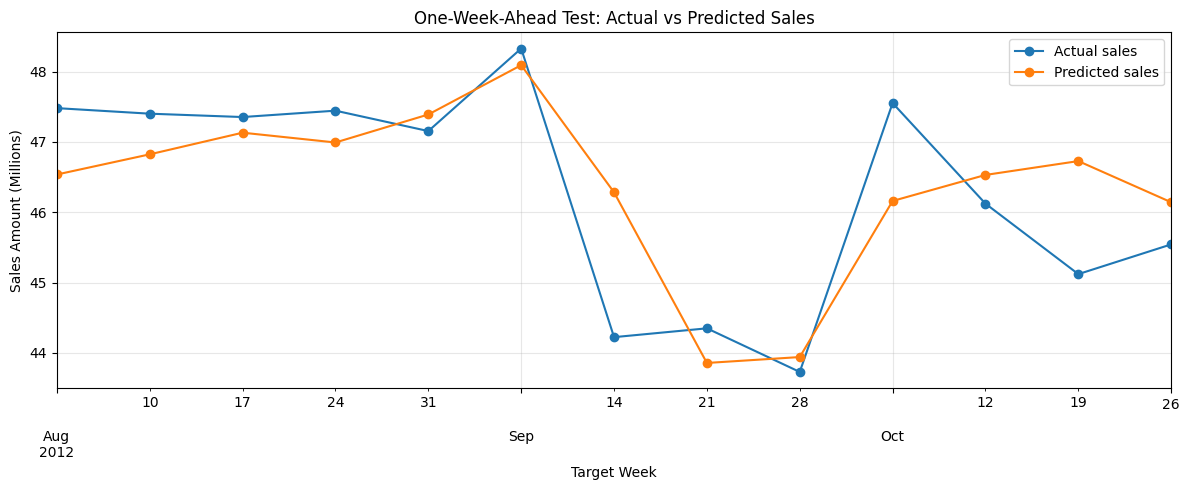

Saved test metrics, predictions, and chart.


In [ ]:
test_weekly_plot = (
    test_scored.groupby("Date")[
        ["Weekly_Sales", "Core_Prediction"]
    ]
    .sum()
    .rename(columns={
        "Weekly_Sales": "Actual sales",
        "Core_Prediction": "Predicted sales"
    })
)

(test_weekly_plot / 1_000_000).plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("One-Week-Ahead Test: Actual vs Predicted Sales")
plt.xlabel("Target Week")
plt.ylabel("Sales Amount (Millions)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_folder / "one_week_test_forecast.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

test_metrics.to_csv(
    output_folder / "one_week_test_metrics.csv",
    index=False
)

test_results.to_csv(
    output_folder / "one_week_test_predictions.csv",
    index=False
)

print("Saved test metrics, predictions, and chart.")

## One-Week Forecasting Findings and Coverage

The selected core model achieved a test MAE of 1276.44,
RMSE of 2652.42, and WAPE of 8.06% on the common comparison
sample. Its MAE was approximately 16.3% lower than the
last-week baseline.

The comparison covered 38,009 of 38,530 test observations.
The remaining 521 observations lacked previous-week sales.

We additionally report model-only performance on all test
observations and on the excluded subset. These results use
different samples and must not be directly compared with
the common-sample baseline metrics.

In [ ]:
coverage_results = []

coverage_groups = [
    ("All test observations", test_results),
    (
        "Missing previous-week sales",
        test_results[test_results["Last_Week_Sales"].isna()]
    )
]

for name, subset in coverage_groups:
    actual = subset["Weekly_Sales"]
    error = subset["Core_Prediction"] - actual
    denominator = actual.abs().sum()

    coverage_results.append({
        "Sample": name,
        "Records": len(subset),
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "WAPE_Percent": (
            error.abs().sum() / denominator * 100
            if denominator > 0 else np.nan
        )
    })

coverage_metrics = pd.DataFrame(coverage_results)

display(coverage_metrics.round(2))

,Sample,Records,MAE,RMSE,WAPE_Percent
0,All test observations,38530,1268.77,2640.73,8.12
1,Missing previous-week sales,521,708.89,1568.42,625.71


## Store-Level Forecast Errors

We calculate store-level metrics on the common test sample
to identify differences hidden by the overall score.

Bias is defined as predicted minus actual sales, normalized
by total absolute actual sales. Positive bias indicates net
overprediction; negative bias indicates net underprediction.

These diagnostics support review and do not change the frozen model.

In [ ]:
store_error_rows = []

for store, group in test_scored.groupby("Store"):
    actual = group["Weekly_Sales"]
    error = group["Core_Prediction"] - actual
    denominator = actual.abs().sum()

    store_error_rows.append({
        "Store": store,
        "Records": len(group),
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "WAPE_Percent": (
            error.abs().sum() / denominator * 100
            if denominator > 0 else np.nan
        ),
        "Bias_Percent": (
            error.sum() / denominator * 100
            if denominator > 0 else np.nan
        )
    })

store_errors = pd.DataFrame(store_error_rows)

display(
    store_errors.sort_values(
        "WAPE_Percent",
        ascending=False
    ).head(10).round(2)
)

,Store,Records,MAE,RMSE,WAPE_Percent,Bias_Percent
28,29,841,909.85,1648.34,11.45,-0.45
15,16,867,892.54,2950.37,11.35,2.82
16,17,895,1525.28,3190.44,11.03,-0.74
4,5,793,577.29,1192.80,10.96,0.10
13,14,905,2561.31,5135.75,10.85,5.38
8,9,800,951.38,1890.01,10.64,-0.52
2,3,814,695.20,1349.20,10.61,-0.61
6,7,878,883.48,1671.16,10.47,5.15
27,28,907,1839.19,3989.70,10.33,0.03
20,21,861,1005.64,1865.30,9.71,1.42


## Visualizing Store-Level Forecast Error

We visualize the ten stores with the highest test WAPE
and save the coverage and store-level diagnostics.

Higher errors identify forecasting review priorities, not
necessarily poorly managed or unprofitable stores.

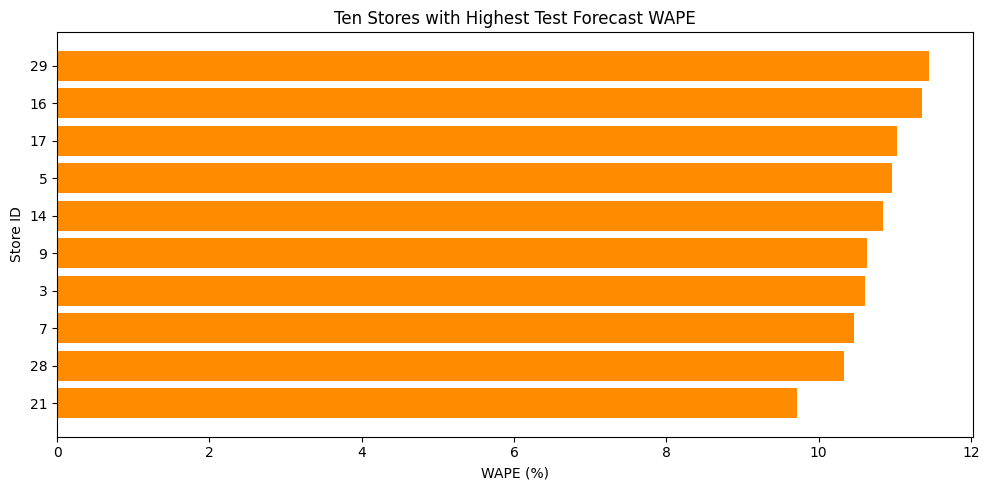

Saved coverage metrics, store errors, and chart.


In [ ]:
highest_error_stores = (
    store_errors.nlargest(10, "WAPE_Percent")
    .sort_values("WAPE_Percent")
)

plt.figure(figsize=(10, 5))

plt.barh(
    highest_error_stores["Store"].astype(str),
    highest_error_stores["WAPE_Percent"],
    color="darkorange"
)

plt.title("Ten Stores with Highest Test Forecast WAPE")
plt.xlabel("WAPE (%)")
plt.ylabel("Store ID")
plt.tight_layout()

plt.savefig(
    output_folder / "store_forecast_errors.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

store_errors.to_csv(
    output_folder / "store_forecast_errors.csv",
    index=False
)

coverage_metrics.to_csv(
    output_folder / "forecast_coverage_metrics.csv",
    index=False
)

print("Saved coverage metrics, store errors, and chart.")

## Preparing a Direct 13-Week Forecast

We define a forecast origin as the week whose sales have already
been observed. The target is sales exactly 13 weeks later for
the same store and department.

Origin sales are valid inputs because they are known when the
forecast is made. Target sales are used only as the outcome to
learn or evaluate, never as an input.

In [ ]:
forecast_horizon = 13

horizon_data = model_data.rename(
    columns={
        "Date": "Origin_Date",
        "Weekly_Sales": "Origin_Sales"
    }
).copy()

horizon_data["Target_Date"] = (
    horizon_data["Origin_Date"]
    + pd.Timedelta(weeks=forecast_horizon)
)

future_targets = sales[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].rename(
    columns={
        "Date": "Target_Date",
        "Weekly_Sales": "Target_Sales"
    }
)

horizon_data = horizon_data.merge(
    future_targets,
    on=["Store", "Dept", "Target_Date"],
    how="left",
    validate="one_to_one"
)

display(
    horizon_data[
        [
            "Store", "Dept", "Origin_Date",
            "Origin_Sales", "Target_Date", "Target_Sales"
        ]
    ].head()
)

,Store,Dept,Origin_Date,Origin_Sales,Target_Date,Target_Sales
0,1,1,2010-02-05,24924.50,2010-05-07,17413.94
1,1,1,2010-02-12,46039.49,2010-05-14,18926.74
2,1,1,2010-02-19,41595.55,2010-05-21,14773.04
3,1,1,2010-02-26,19403.54,2010-05-28,15580.43
4,1,1,2010-03-05,21827.90,2010-06-04,17558.09


## Target Calendar Features and Seasonal Reference

We create calendar features for the target week. Holiday flags
are treated as calendar information known at the forecast origin.

The seasonal baseline uses sales 52 weeks before the target date.
For a 13-week horizon, this reference is 39 weeks before the origin,
so it is historical information.

If that reference is unavailable, the baseline uses origin sales.
Actual future weather, economic indicators, and markdowns are excluded.

In [ ]:
horizon_data["Target_Year"] = (
    horizon_data["Target_Date"].dt.year
)
horizon_data["Target_Month"] = (
    horizon_data["Target_Date"].dt.month
)
horizon_data["Target_Week"] = (
    horizon_data["Target_Date"].dt.isocalendar().week.astype(int)
)
horizon_data["Target_Quarter"] = (
    horizon_data["Target_Date"].dt.quarter
)

target_calendar = features[
    ["Store", "Date", "IsHoliday"]
].rename(
    columns={
        "Date": "Target_Date",
        "IsHoliday": "Target_IsHoliday"
    }
)

horizon_data = horizon_data.merge(
    target_calendar,
    on=["Store", "Target_Date"],
    how="left",
    validate="many_to_one"
)

seasonal_reference = sales[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].rename(
    columns={
        "Date": "Target_Date",
        "Weekly_Sales": "Target_Seasonal_Sales"
    }
)

seasonal_reference["Target_Date"] += pd.Timedelta(weeks=52)

horizon_data = horizon_data.merge(
    seasonal_reference,
    on=["Store", "Dept", "Target_Date"],
    how="left",
    validate="one_to_one"
)

horizon_data["Seasonal_Baseline_13W"] = (
    horizon_data["Target_Seasonal_Sales"]
    .fillna(horizon_data["Origin_Sales"])
)

display(
    horizon_data[
        [
            "Origin_Date", "Target_Date",
            "Target_Month", "Target_Week",
            "Target_IsHoliday", "Seasonal_Baseline_13W"
        ]
    ].head()
)

,Origin_Date,Target_Date,Target_Month,Target_Week,Target_IsHoliday,Seasonal_Baseline_13W
0,2010-02-05,2010-05-07,5,18,False,24924.50
1,2010-02-12,2010-05-14,5,19,False,46039.49
2,2010-02-19,2010-05-21,5,20,False,41595.55
3,2010-02-26,2010-05-28,5,21,False,19403.54
4,2010-03-05,2010-06-04,6,22,False,21827.90


## Chronological Splits for the 13-Week Horizon

We use the same final test target period as the one-week analysis.
However, its earliest forecast origin occurs 13 weeks earlier.

Validation targets must be observed by that earliest test origin,
and training targets must be observed by the earliest validation
origin. These gaps protect both training and model selection
from future information.

In [ ]:
required_variables = [
    "pd",
    "sales",
    "features",
    "model_data",
    "test_start",
    "horizon_data"
]

for name in required_variables:
    print(name, "→", "Available" if name in globals() else "Missing")

pd → Available
sales → Available
features → Available
model_data → Available
test_start → Available
horizon_data → Available


In [ ]:
horizon_observed = horizon_data.dropna(
    subset=["Target_Sales"]
).copy()

test_origin_start_13 = (
    test_start - pd.Timedelta(weeks=13)
)

validation_end_13 = test_origin_start_13
validation_start_13 = (
    validation_end_13 - pd.Timedelta(weeks=12)
)

training_end_13 = (
    validation_start_13 - pd.Timedelta(weeks=13)
)

train_13 = horizon_observed[
    horizon_observed["Target_Date"] <= training_end_13
].copy()

validation_13 = horizon_observed[
    horizon_observed["Target_Date"].between(
        validation_start_13,
        validation_end_13
    )
].copy()

test_13 = horizon_observed[
    horizon_observed["Target_Date"] >= test_start
].copy()

assert (
    train_13["Target_Date"].max()
    <= validation_13["Origin_Date"].min()
)

assert (
    validation_13["Target_Date"].max()
    <= test_13["Origin_Date"].min()
)

print("Training target cutoff:", training_end_13.date())
print("Validation targets:", validation_start_13.date(),
      "to", validation_end_13.date())
print("Earliest test origin:", test_origin_start_13.date())
print("Test targets start:", test_start.date())

Training target cutoff: 2011-11-11
Validation targets: 2012-02-10 to 2012-05-04
Earliest test origin: 2012-05-04
Test targets start: 2012-08-03


## Selecting Inputs for the 13-Week Model

We use store attributes, sales available at the forecast origin,
historical sales summaries, and the target week's calendar features.

Target sales are excluded from inputs. Numerical features with
no variation in training are excluded using training data only.

In [ ]:
categorical_features_13 = ["Store", "Dept", "Type"]

numeric_features_13 = [
    "Size",
    "Origin_Sales",
    "Last_Week_Sales",
    "Sales_52_Weeks_Ago",
    "Sales_Lag_2",
    "Sales_Lag_4",
    "Sales_Lag_8",
    "Recent_Sales_Mean",
    "Recent_Sales_Std",
    "Available_Recent_Lags",
    "Target_Seasonal_Sales",
    "Target_Year",
    "Target_Month",
    "Target_Week",
    "Target_Quarter",
    "Target_IsHoliday"
]

for dataset in [train_13, validation_13, test_13]:
    dataset["Target_IsHoliday"] = (
        dataset["Target_IsHoliday"].astype("float64")
    )

usable_numeric_13 = [
    column for column in numeric_features_13
    if train_13[column].nunique(dropna=True) > 1
]

forecast_features_13 = (
    categorical_features_13 + usable_numeric_13
)

X_train_13 = train_13[forecast_features_13].copy()
y_train_13 = train_13["Target_Sales"].copy()

X_validation_13 = validation_13[forecast_features_13].copy()
y_validation_13 = validation_13["Target_Sales"].copy()

assert "Target_Sales" not in forecast_features_13
assert X_train_13.index.equals(y_train_13.index)

print("Training inputs:", X_train_13.shape)
print("Validation inputs:", X_validation_13.shape)

print(
    "Excluded columns:",
    [
        column for column in numeric_features_13
        if column not in usable_numeric_13
    ]
)

Training inputs: (229809, 19)
Validation inputs: (37954, 19)
Excluded columns: []


## Training a Direct 13-Week Forecasting Model

We train a separate gradient boosting model to predict sales
exactly 13 weeks after each forecast origin.

Fresh preprocessing is fitted only on the horizon-specific
training data. Regression settings remain fixed. This is a direct
forecast rather than repeated one-week predictions.

In [ ]:
from sklearn.base import clone

preprocessor_13 = ColumnTransformer(
    transformers=[
        (
            "categories",
            clone(categorical_preprocessor),
            categorical_features_13
        ),
        (
            "numbers",
            clone(numeric_preprocessor),
            usable_numeric_13
        )
    ],
    remainder="drop"
)

forecast_model_13 = Pipeline(
    steps=[
        ("preprocessing", preprocessor_13),
        (
            "regression",
            clone(forecast_model.named_steps["regression"])
        )
    ]
)

forecast_model_13.fit(X_train_13, y_train_13)

validation_13["Model_Prediction_13W"] = (
    forecast_model_13.predict(X_validation_13)
)

print("13-week model trained.")
print("Validation predictions generated.")

13-week model trained.
Validation predictions generated.


## Comparing 13-Week Forecasting Approaches

We compare the direct model with origin-sales and seasonal
baselines on identical validation observations.

We select the approach with the lowest validation MAE.
Baselines remain eligible: a complex model is not preferred
unless its validation results support that choice.

The 13-week test outcomes are not used in this selection.

In [ ]:
validation_results_13 = []

for name, column in [
    ("Origin-sales baseline", "Origin_Sales"),
    ("Seasonal baseline", "Seasonal_Baseline_13W"),
    ("Direct 13-week boosting", "Model_Prediction_13W")
]:
    actual = validation_13["Target_Sales"]
    predicted = validation_13[column]

    assert predicted.notna().all()

    error = actual - predicted

    validation_results_13.append({
        "Model": name,
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "WAPE_Percent": (
            error.abs().sum() / actual.abs().sum() * 100
        )
    })

comparison_13 = pd.DataFrame(validation_results_13)

display(comparison_13.round(2))

best_13_name = comparison_13.loc[
    comparison_13["MAE"].idxmin(),
    "Model"
]

print("Selected approach:", best_13_name)

comparison_13.to_csv(
    output_folder / "validation_13_week_comparison.csv",
    index=False
)

,Model,MAE,RMSE,WAPE_Percent
0,Origin-sales baseline,4602.09,13384.37,28.48
1,Seasonal baseline,2017.54,4498.90,12.48
2,Direct 13-week boosting,2088.43,4266.38,12.92


Selected approach: Seasonal baseline


## Finalizing the 13-Week Forecasting Approach

The seasonal baseline achieved the lowest validation MAE,
although boosting achieved a lower RMSE. We retain MAE as
the selection criterion and select the seasonal baseline.

This baseline requires no model refitting. It uses sales
52 weeks before each target date, falling back to origin sales
when the seasonal reference is unavailable.

In [ ]:
assert best_13_name == "Seasonal baseline", (
    "The selected approach differs. Review before continuing."
)

test_results_13 = test_13[
    [
        "Store",
        "Dept",
        "Origin_Date",
        "Target_Date",
        "Origin_Sales",
        "Target_Sales",
        "Target_Seasonal_Sales",
        "Seasonal_Baseline_13W"
    ]
].copy()

test_results_13["Selected_Prediction"] = (
    test_results_13["Seasonal_Baseline_13W"]
)

test_results_13["Used_Fallback"] = (
    test_results_13["Target_Seasonal_Sales"].isna()
)

assert test_results_13["Selected_Prediction"].notna().all()

assert (
    test_results_13["Target_Date"]
    - test_results_13["Origin_Date"]
).eq(pd.Timedelta(weeks=13)).all()

print("Test observations:", len(test_results_13))
print(
    "Fallback observations:",
    test_results_13["Used_Fallback"].sum()
)

display(test_results_13.head())

Test observations: 37641
Fallback observations: 587


,Store,Dept,Origin_Date,Target_Date,Origin_Sales,Target_Sales,Target_Seasonal_Sales,Seasonal_Baseline_13W,Selected_Prediction,Used_Fallback
117,1,1,2012-05-04,2012-08-03,17147.44,16628.31,15295.55,15295.55,15295.55,False
118,1,1,2012-05-11,2012-08-10,18164.20,16119.92,14539.79,14539.79,14539.79,False
119,1,1,2012-05-18,2012-08-17,18517.79,17330.70,14689.24,14689.24,14689.24,False
120,1,1,2012-05-25,2012-08-24,16963.55,16286.40,14537.37,14537.37,14537.37,False
121,1,1,2012-06-01,2012-08-31,16065.49,16680.24,15277.27,15277.27,15277.27,False


## Evaluating the Selected 13-Week Approach

We evaluate the selected seasonal baseline and the origin-sales
reference on identical test observations.

The selection is frozen before this evaluation. Test results
describe performance on the observed store-department pairs;
pairs without an observed origin or target are not evaluated.

In [ ]:
test_metric_rows_13 = []

for name, column in [
    ("Origin-sales baseline", "Origin_Sales"),
    ("Selected seasonal baseline", "Selected_Prediction")
]:
    actual = test_results_13["Target_Sales"]
    predicted = test_results_13[column]

    error = actual - predicted

    test_metric_rows_13.append({
        "Model": name,
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "WAPE_Percent": (
            error.abs().sum() / actual.abs().sum() * 100
        )
    })

test_metrics_13 = pd.DataFrame(test_metric_rows_13)

display(test_metrics_13.round(2))

,Model,MAE,RMSE,WAPE_Percent
0,Origin-sales baseline,2788.14,6135.64,17.48
1,Selected seasonal baseline,1701.58,3640.31,10.67


## Visualizing the 13-Week Test Forecast

We compare weekly totals of actual sales and selected seasonal
predictions for the scored test observations.

Each target week's prediction was formed from information
available at its corresponding origin 13 weeks earlier.
The chart represents rolling origins, not one fixed-origin
forecast covering the entire test period.

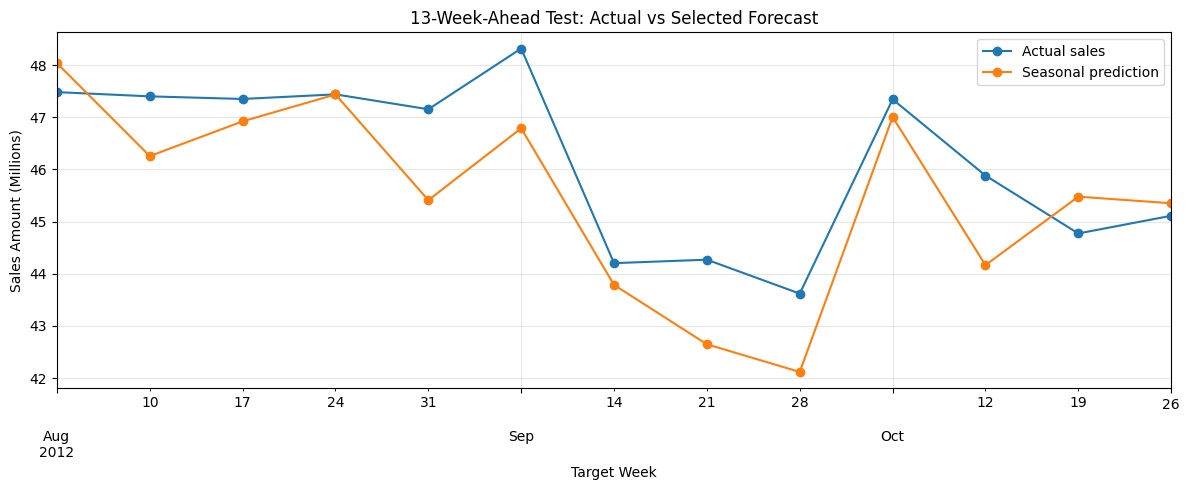

Saved 13-week test metrics, predictions, and chart.


In [ ]:
weekly_test_13 = (
    test_results_13.groupby("Target_Date")[
        ["Target_Sales", "Selected_Prediction"]
    ]
    .sum()
    .rename(columns={
        "Target_Sales": "Actual sales",
        "Selected_Prediction": "Seasonal prediction"
    })
)

(weekly_test_13 / 1_000_000).plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("13-Week-Ahead Test: Actual vs Selected Forecast")
plt.xlabel("Target Week")
plt.ylabel("Sales Amount (Millions)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_folder / "13_week_test_forecast.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

test_metrics_13.to_csv(
    output_folder / "13_week_test_metrics.csv",
    index=False
)

test_results_13.to_csv(
    output_folder / "13_week_test_predictions.csv",
    index=False
)

print("Saved 13-week test metrics, predictions, and chart.")

## Saving Forecasting Artifacts

We save the fitted one-week forecasting pipeline, its input
feature names, and the selected 13-week seasonal forecasting rule.

The one-week pipeline includes fitted preprocessing. The seasonal
baseline has no fitted estimator, so its horizon, reference lag,
and fallback rule are recorded instead.

Package versions are saved to support reproducibility.

In [ ]:
import joblib
import sklearn

model_folder = data_folder.parent / "models"
model_folder.mkdir(parents=True, exist_ok=True)

forecast_bundle = {
    "one_week": {
        "pipeline": final_core_model,
        "features": forecast_features,
        "horizon_weeks": 1,
        "training_target_end": str(
            final_training_data["Date"].max().date()
        )
    },
    "thirteen_week": {
        "selected_method": "Seasonal baseline",
        "horizon_weeks": 13,
        "seasonal_reference_weeks_before_target": 52,
        "fallback": "Sales observed at forecast origin"
    },
    "versions": {
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__
    }
}

forecast_path = model_folder / "forecasting_artifacts.joblib"

joblib.dump(forecast_bundle, forecast_path)

print("Forecasting artifacts saved:", forecast_path.exists())
print("Location:", forecast_path)

Forecasting artifacts saved: True
Location: /content/drive/MyDrive/Retail_Analytics_Project/models/forecasting_artifacts.joblib


## Saving Segmentation and Anomaly Artifacts

We save the clustering model with its fitted scaler and feature
order. We also save Isolation Forest with its training medians
and input columns.

The robust detector's training statistics and threshold are
preserved so that later observations can be evaluated using
the same rules.

In [ ]:
analysis_bundle = {
    "segmentation": {
        "model": best_cluster_model,
        "scaler": cluster_scaler,
        "features": cluster_features,
        "segment_names": segment_names
    },
    "isolation_forest": {
        "model": isolation_model,
        "features": anomaly_features,
        "training_medians": training_medians
    },
    "robust_detector": {
        "training_statistics": change_stats,
        "threshold": 5,
        "minimum_valid_changes": 20,
        "mad_scale_factor": 1.4826
    },
    "training_date_exclusive_end": str(validation_start.date()),
    "versions": forecast_bundle["versions"]
}

analysis_path = model_folder / "analysis_artifacts.joblib"

joblib.dump(analysis_bundle, analysis_path)

print("Analysis artifacts saved:", analysis_path.exists())
print("Location:", analysis_path)

Analysis artifacts saved: True
Location: /content/drive/MyDrive/Retail_Analytics_Project/models/analysis_artifacts.joblib


## Verifying Model Reloading

We reload the forecasting artifact and compare predictions
against the original in-memory pipeline on five test inputs.

Matching predictions confirm that serialization preserved the
pipeline's behavior on these inputs. This does not replace
forecast evaluation or validate future deployment conditions.

In [ ]:
loaded_forecast = joblib.load(forecast_path)

loaded_pipeline = loaded_forecast["one_week"]["pipeline"]
loaded_features = loaded_forecast["one_week"]["features"]

sample_inputs = X_test_core.loc[:, loaded_features].head(5)

original_predictions = final_core_model.predict(sample_inputs)
reloaded_predictions = loaded_pipeline.predict(sample_inputs)

np.testing.assert_allclose(
    original_predictions,
    reloaded_predictions,
    rtol=1e-10,
    atol=1e-8
)

display(
    pd.DataFrame({
        "Original_Prediction": original_predictions,
        "Reloaded_Prediction": reloaded_predictions
    }).round(2)
)

print("Reload verification passed: predictions match.")

,Original_Prediction,Reloaded_Prediction
0,16795.48,16795.48
1,17112.57,17112.57
2,17299.20,17299.20
3,17410.85,17410.85
4,17299.20,17299.20


Reload verification passed: predictions match.


## Refitting for Future Forecasting

After completing evaluation, we refit the selected one-week
pipeline on all available historical sales without changing
its settings.

The evaluation model remains separate. The newly fitted model
is used for forecasts beyond the observed dataset.

Forecast coverage is restricted to store-department pairs
observed in the latest sales week.

In [ ]:
last_observed_date = model_data["Date"].max()

future_core_model = clone(final_core_model)

future_core_model.fit(
    model_data[forecast_features],
    model_data["Weekly_Sales"]
)

active_pairs = model_data.loc[
    model_data["Date"] == last_observed_date,
    ["Store", "Dept", "Type", "Size"]
].copy()

assert not active_pairs.duplicated(["Store", "Dept"]).any()

print("Last observed date:", last_observed_date.date())
print("Store-department pairs to forecast:", len(active_pairs))
print("Future forecasting model trained.")

Last observed date: 2012-10-26
Store-department pairs to forecast: 2959
Future forecasting model trained.


## Forecasting the Next Week

We construct next-week inputs using exact historical sales lags,
store attributes, and known calendar information.

Target-week actual sales and external measurements are not used.
The holiday flag is treated as advance calendar information.
Missing history is handled by the fitted preprocessing pipeline.

In [ ]:
next_week_date = last_observed_date + pd.Timedelta(weeks=1)

future_inputs = active_pairs.copy()
future_inputs["Date"] = next_week_date

future_inputs["Year"] = future_inputs["Date"].dt.year
future_inputs["Month"] = future_inputs["Date"].dt.month
future_inputs["WeekOfYear"] = (
    future_inputs["Date"].dt.isocalendar().week.astype(int)
)
future_inputs["Quarter"] = future_inputs["Date"].dt.quarter

future_inputs = future_inputs.merge(
    features[["Store", "Date", "IsHoliday"]],
    on=["Store", "Date"],
    how="left",
    validate="many_to_one"
)

assert future_inputs["IsHoliday"].notna().all(), (
    "Future holiday calendar information is missing."
)

sales_lookup = merged_data.set_index(
    ["Store", "Dept", "Date"]
)["Weekly_Sales"]

lag_definitions = {
    "Last_Week_Sales": 1,
    "Sales_52_Weeks_Ago": 52,
    "Sales_Lag_2": 2,
    "Sales_Lag_4": 4,
    "Sales_Lag_8": 8
}

for column, weeks in lag_definitions.items():
    lookup_keys = pd.MultiIndex.from_arrays([
        future_inputs["Store"],
        future_inputs["Dept"],
        future_inputs["Date"] - pd.Timedelta(weeks=weeks)
    ])

    future_inputs[column] = (
        sales_lookup.reindex(lookup_keys).to_numpy()
    )

future_inputs["Recent_Sales_Mean"] = (
    future_inputs[recent_lag_columns].mean(axis=1)
)
future_inputs["Recent_Sales_Std"] = (
    future_inputs[recent_lag_columns].std(axis=1)
)
future_inputs["Available_Recent_Lags"] = (
    future_inputs[recent_lag_columns].notna().sum(axis=1)
)

future_one_week = future_inputs[
    ["Store", "Dept", "Date"]
].rename(columns={"Date": "Target_Date"})

future_one_week["Prediction"] = future_core_model.predict(
    future_inputs[forecast_features]
)

future_one_week["Origin_Date"] = last_observed_date
future_one_week["Horizon_Weeks"] = 1
future_one_week["Method"] = "Core gradient boosting"

display(future_one_week.head().round(2))

,Store,Dept,Target_Date,Prediction,Origin_Date,Horizon_Weeks,Method
0,1,1,2012-11-02,35911.69,2012-10-26,1,Core gradient boosting
1,1,2,2012-11-02,46138.10,2012-10-26,1,Core gradient boosting
2,1,3,2012-11-02,9644.02,2012-10-26,1,Core gradient boosting
3,1,4,2012-11-02,37786.84,2012-10-26,1,Core gradient boosting
4,1,5,2012-11-02,29307.98,2012-10-26,1,Core gradient boosting


## Producing and Saving Future Forecasts

For the selected 13-week seasonal approach, we use sales
52 weeks before the target date. If unavailable, we use
sales observed at the forecast origin.

We save forecasts for two target weeks: one week and thirteen
weeks after the dataset ends. These are not forecasts for
every intervening week. Actual future outcomes are unavailable,
so forecast errors cannot yet be calculated.

In [ ]:
target_date_13 = last_observed_date + pd.Timedelta(weeks=13)

future_thirteen_week = active_pairs[["Store", "Dept"]].copy()
future_thirteen_week["Target_Date"] = target_date_13

seasonal_keys = pd.MultiIndex.from_arrays([
    future_thirteen_week["Store"],
    future_thirteen_week["Dept"],
    future_thirteen_week["Target_Date"] - pd.Timedelta(weeks=52)
])

origin_keys = pd.MultiIndex.from_arrays([
    future_thirteen_week["Store"],
    future_thirteen_week["Dept"],
    pd.Series(
        last_observed_date,
        index=future_thirteen_week.index
    )
])

future_thirteen_week["Seasonal_Reference"] = (
    sales_lookup.reindex(seasonal_keys).to_numpy()
)

future_thirteen_week["Origin_Sales"] = (
    sales_lookup.reindex(origin_keys).to_numpy()
)

future_thirteen_week["Used_Fallback"] = (
    future_thirteen_week["Seasonal_Reference"].isna()
)

future_thirteen_week["Prediction"] = (
    future_thirteen_week["Seasonal_Reference"]
    .fillna(future_thirteen_week["Origin_Sales"])
)

future_thirteen_week["Origin_Date"] = last_observed_date
future_thirteen_week["Horizon_Weeks"] = 13
future_thirteen_week["Method"] = "Seasonal baseline"

assert future_thirteen_week["Prediction"].notna().all()

future_one_week.to_csv(
    output_folder / "future_one_week_forecast.csv",
    index=False
)

future_thirteen_week.to_csv(
    output_folder / "future_thirteen_week_forecast.csv",
    index=False
)

joblib.dump(
    {
        "pipeline": future_core_model,
        "features": forecast_features,
        "training_end": str(last_observed_date.date()),
        "horizon_weeks": 1,
        "versions": forecast_bundle["versions"]
    },
    model_folder / "future_one_week_model.joblib"
)

display(future_thirteen_week.head().round(2))

print("One-week target:", next_week_date.date())
print("13-week target:", target_date_13.date())
print("Future forecasts and refitted model saved.")

,Store,Dept,Target_Date,Seasonal_Reference,Origin_Sales,Used_Fallback,Prediction,Origin_Date,Horizon_Weeks,Method
142,1,1,2013-01-25,18378.16,27390.81,False,18378.16,2012-10-26,13,Seasonal baseline
285,1,2,2013-01-25,41556.23,43134.88,False,41556.23,2012-10-26,13,Seasonal baseline
428,1,3,2013-01-25,10613.17,9350.90,False,10613.17,2012-10-26,13,Seasonal baseline
571,1,4,2013-01-25,33613.91,36292.60,False,33613.91,2012-10-26,13,Seasonal baseline
714,1,5,2013-01-25,21376.42,25846.94,False,21376.42,2012-10-26,13,Seasonal baseline


One-week target: 2012-11-02
13-week target: 2013-01-25
Future forecasts and refitted model saved.


## Forecast Performance Across Store Segments

We evaluate the selected one-week model separately for each
training-defined store segment using the common test sample.

Segment WAPE is calculated from pooled absolute errors and
absolute actual sales, rather than averaging store percentages.
These diagnostics identify planning risks without changing
the frozen model.

In [ ]:
segment_test = test_scored.merge(
    store_profiles[["Store", "Segment", "Segment_Name"]],
    on="Store",
    how="left",
    validate="many_to_one"
)

assert segment_test["Segment"].notna().all()

segment_error_rows = []

for segment, group in segment_test.groupby("Segment"):
    actual = group["Weekly_Sales"]
    error = group["Core_Prediction"] - actual
    denominator = actual.abs().sum()

    segment_error_rows.append({
        "Segment": segment,
        "Segment_Name": group["Segment_Name"].iloc[0],
        "Stores": group["Store"].nunique(),
        "Scored_Records": len(group),
        "MAE": error.abs().mean(),
        "WAPE_Percent": (
            error.abs().sum() / denominator * 100
            if denominator > 0 else np.nan
        ),
        "Bias_Percent": (
            error.sum() / denominator * 100
            if denominator > 0 else np.nan
        )
    })

segment_errors = pd.DataFrame(segment_error_rows)

display(segment_errors.round(2))

segment_errors.to_csv(
    output_folder / "segment_forecast_errors.csv",
    index=False
)

,Segment,Segment_Name,Stores,Scored_Records,MAE,WAPE_Percent,Bias_Percent
0,0,"Larger stores, higher sales",35,31385,1419.12,8.14,0.17
1,1,"Smaller stores, lower variability",10,6624,600.45,7.29,-0.26


## Segment-Level Future Sales Planning

We summarize future sales forecasts by segment, target date,
and forecast horizon.

The one-week and thirteen-week forecasts refer to different
target weeks and use different approaches. Their totals are
kept separate and should not be treated as cumulative demand
or directly interpreted as a growth forecast.

In [ ]:
forecast_summary_columns = [
    "Store", "Dept", "Target_Date",
    "Horizon_Weeks", "Prediction"
]

future_combined = pd.concat(
    [
        future_one_week[forecast_summary_columns],
        future_thirteen_week[forecast_summary_columns]
    ],
    ignore_index=True
)

future_combined = future_combined.merge(
    store_profiles[["Store", "Segment", "Segment_Name"]],
    on="Store",
    how="left",
    validate="many_to_one"
)

assert future_combined["Segment"].notna().all()

segment_future_forecasts = (
    future_combined.groupby(
        ["Segment_Name", "Target_Date", "Horizon_Weeks"],
        as_index=False
    )
    .agg(
        Stores=("Store", "nunique"),
        Department_Records=("Dept", "size"),
        Predicted_Sales=("Prediction", "sum")
    )
)

display(segment_future_forecasts.round(2))

segment_future_forecasts.to_csv(
    output_folder / "segment_future_forecasts.csv",
    index=False
)

,Segment_Name,Target_Date,Horizon_Weeks,Stores,Department_Records,Predicted_Sales
0,"Larger stores, higher sales",2012-11-02,1,35,2435,43703343.31
1,"Larger stores, higher sales",2013-01-25,13,35,2435,35868089.49
2,"Smaller stores, lower variability",2012-11-02,1,10,524,4312620.51
3,"Smaller stores, lower variability",2013-01-25,13,10,524,3978838.08


## Inventory and Marketing Recommendations

We propose differentiated planning actions based on observed
segment characteristics.

Higher-variability stores require closer forecast review.
More stable stores can use regular planning cycles with exception
monitoring. Holiday patterns motivate controlled promotional
pilots, not claims of proven promotion effectiveness.

Sales forecasts are monetary amounts. Reorder quantities and
safety stock require unit demand, inventory, lead times, and
service-level targets, which are unavailable.

In [ ]:
higher_variability_segment = (
    segment_summary["Mean_Sales_CV"].idxmax()
)

strategy_rows = []

for segment, profile in segment_summary.iterrows():
    higher_variability = (
        segment == higher_variability_segment
    )

    strategy_rows.append({
        "Segment": segment,
        "Segment_Name": segment_names[segment],
        "Mean_Sales_CV": profile["Mean_Sales_CV"],
        "Mean_Holiday_Ratio": profile["Mean_Holiday_Ratio"],
        "Inventory_Planning": (
            "Review forecasts and large sales changes weekly; "
            "check stock and lead times before adjusting orders."
            if higher_variability else
            "Use a regular replenishment review cycle with "
            "alerts for deviations from the usual sales pattern."
        ),
        "Marketing_Pilot": (
            "Test holiday-timed campaigns against comparable "
            "holdout stores; evaluate incremental margin."
            if higher_variability else
            "Test smaller targeted campaigns with holdout stores; "
            "check whether benefits justify promotion costs."
        ),
        "Required_Additional_Data": (
            "Unit sales, stock levels, lead times, margins, "
            "promotion costs and transaction records."
        )
    })

strategy_table = pd.DataFrame(strategy_rows)

display(strategy_table)

strategy_table.to_csv(
    output_folder / "segment_business_strategies.csv",
    index=False
)

print("Segment strategy table saved.")

,Segment,Segment_Name,Mean_Sales_CV,Mean_Holiday_Ratio,Inventory_Planning,Marketing_Pilot,Required_Additional_Data
0,0,"Larger stores, higher sales",0.154457,1.096306,Review forecasts and large sales changes weekl...,Test holiday-timed campaigns against comparabl...,"Unit sales, stock levels, lead times, margins,..."
1,1,"Smaller stores, lower variability",0.092178,1.018500,Use a regular replenishment review cycle with ...,Test smaller targeted campaigns with holdout s...,"Unit sales, stock levels, lead times, margins,..."


Segment strategy table saved.


## Checking Clustering Initialization Stability

We repeat K-Means with different random seeds while keeping
the same features and number of clusters.

Adjusted Rand Index (ARI) compares each result with the selected
clustering, accounting for arbitrary cluster label numbering.
An ARI of 1 indicates identical group assignments.

This checks sensitivity to initialization only. It does not
establish stability across different samples or future periods.

In [ ]:
from sklearn.metrics import adjusted_rand_score

stability_results = []

reference_labels = best_cluster_model.labels_

for seed in [0, 10, 21, 42, 100]:
    repeat_model = KMeans(
        n_clusters=best_k,
        n_init=20,
        random_state=seed
    )

    repeat_labels = repeat_model.fit_predict(
        scaled_store_features
    )

    stability_results.append({
        "Random_Seed": seed,
        "ARI_vs_Selected_Model": adjusted_rand_score(
            reference_labels,
            repeat_labels
        )
    })

cluster_stability = pd.DataFrame(stability_results)

display(cluster_stability.round(3))

cluster_stability.to_csv(
    output_folder / "cluster_initialization_stability.csv",
    index=False
)

,Random_Seed,ARI_vs_Selected_Model
0,0,0.901
1,10,0.901
2,21,0.901
3,42,1.000
4,100,0.901


## Final Consistency Checks

We verify that merging preserved sales rows and totals, forecast
splits respect time boundaries, and future predictions have
unique keys and finite values.

These checks detect implementation issues. They do not prove
that forecasts will be accurate or that all data-quality issues
have been resolved.

In [ ]:
# Merging must preserve observed sales.
assert len(merged_data) == len(sales)

assert np.isclose(
    merged_data["Weekly_Sales"].sum(),
    sales["Weekly_Sales"].sum()
)

assert not merged_data.duplicated(
    ["Store", "Dept", "Date"]
).any()

# One-week evaluation cutoff.
assert (
    final_training_data["Date"].max()
    <= test_model_data["Date"].min() - pd.Timedelta(weeks=1)
)

# Thirteen-week training and selection cutoffs.
assert (
    train_13["Target_Date"].max()
    <= validation_13["Origin_Date"].min()
)

assert (
    validation_13["Target_Date"].max()
    <= test_13["Origin_Date"].min()
)

# Future forecast checks.
for forecast_frame, horizon in [
    (future_one_week, 1),
    (future_thirteen_week, 13)
]:
    assert not forecast_frame.duplicated(
        ["Store", "Dept", "Target_Date"]
    ).any()

    assert np.isfinite(
        forecast_frame["Prediction"].to_numpy()
    ).all()

    assert (
        forecast_frame["Target_Date"]
        - forecast_frame["Origin_Date"]
    ).eq(pd.Timedelta(weeks=horizon)).all()

    assert (
        forecast_frame["Target_Date"] > last_observed_date
    ).all()

print("Sales row count and totals preserved.")
print("Record keys are unique.")
print("Forecast time boundaries passed.")
print("Future forecast keys, values, and horizons passed.")

Sales row count and totals preserved.
Record keys are unique.
Forecast time boundaries passed.
Future forecast keys, values, and horizons passed.


## Project Results Summary

We consolidate the selected approaches, test performance,
segmentation results, and analytical limitations.

The summary distinguishes sales-amount forecasts from unit demand
and department associations from actual customer baskets.
It forms a starting point for the detailed project documentation.

In [ ]:
report_folder = data_folder.parent / "reports"
report_folder.mkdir(parents=True, exist_ok=True)

one_week_metrics = test_metrics.loc[
    test_metrics["Model"] == "Selected core model"
].iloc[0]

thirteen_week_metrics = test_metrics_13.loc[
    test_metrics_13["Model"] == "Selected seasonal baseline"
].iloc[0]

selected_cluster_quality = cluster_quality.loc[
    cluster_quality["Clusters"] == best_k
].iloc[0]

summary_text = f"""# Integrated Retail Analytics: Results Summary

## Data
- Sales observations: {len(sales):,}
- Stores: {sales["Store"].nunique()}
- Department IDs: {sales["Dept"].nunique()}
- Sales period: {sales["Date"].min().date()} to {last_observed_date.date()}
- Raw source files were preserved.

## One-Week Forecasting
Selected approach: Core gradient boosting.
- Test MAE: {one_week_metrics["MAE"]:.2f}
- Test RMSE: {one_week_metrics["RMSE"]:.2f}
- Test WAPE: {one_week_metrics["WAPE_Percent"]:.2f}%
- Common comparison observations: {len(test_scored):,}

Adding lagged external features did not improve validation MAE
under the tested settings.

## Thirteen-Week Forecasting
Selected approach: Seasonal baseline, chosen by validation MAE.
- Test MAE: {thirteen_week_metrics["MAE"]:.2f}
- Test RMSE: {thirteen_week_metrics["RMSE"]:.2f}
- Test WAPE: {thirteen_week_metrics["WAPE_Percent"]:.2f}%
- Evaluated observations: {len(test_results_13):,}

Both evaluations use rolling forecast origins. Different horizons
may cover different store-department observations.

## Store Segmentation
- Selected clusters: {best_k}
- Silhouette: {selected_cluster_quality["Silhouette"]:.3f}
- Davies-Bouldin: {selected_cluster_quality["Davies_Bouldin"]:.3f}

Segments describe stores, not individual customers.
Initialization stability results are saved separately.

## Anomalies and Department Associations
Unusual observations were flagged for review rather than
automatically deleted. Verified anomaly labels are unavailable.

Department rules describe co-occurring strong-sales events.
They do not establish joint purchases or causal relationships.

## Future Forecasts
- One-week target: {next_week_date.date()}
- Thirteen-week target: {target_date_13.date()}
- Forecasts cover pairs observed in the latest sales week.
- Predictions are sales amounts, not product quantities.

## Business Application
Use segment-specific planning reviews and controlled marketing
pilots. Reorder quantities require unit demand, stock levels,
lead times, and service targets.

## Limitations
Missing markdowns remain unknown. External-factor comparisons
are predictive, not causal. Prediction intervals and broader
historical backtesting are not included in this version.

## Submission Work Remaining
Adapt to the official template if supplied, write detailed
Google Docs documentation, publish the GitHub repository,
verify sharing permissions, and record the presentation.
"""

summary_path = report_folder / "project_results_summary.md"

summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("\nSaved:", summary_path)

# Integrated Retail Analytics: Results Summary

## Data
- Sales observations: 421,570
- Stores: 45
- Department IDs: 81
- Sales period: 2010-02-05 to 2012-10-26
- Raw source files were preserved.

## One-Week Forecasting
Selected approach: Core gradient boosting.
- Test MAE: 1276.44
- Test RMSE: 2652.42
- Test WAPE: 8.06%
- Common comparison observations: 38,009

Adding lagged external features did not improve validation MAE
under the tested settings.

## Thirteen-Week Forecasting
Selected approach: Seasonal baseline, chosen by validation MAE.
- Test MAE: 1701.58
- Test RMSE: 3640.31
- Test WAPE: 10.67%
- Evaluated observations: 37,641

Both evaluations use rolling forecast origins. Different horizons
may cover different store-department observations.

## Store Segmentation
- Selected clusters: 2
- Silhouette: 0.457
- Davies-Bouldin: 0.822

Segments describe stores, not individual customers.
Initialization stability results are saved separately.

## Anomalies and Department Association

## Exporting Supporting Analysis Tables

We save the data-quality summary, missing-value summary, and
anomaly review examples for documentation.

The anomaly export is a review shortlist, not a list of confirmed
errors. Original sales values remain unchanged.

In [ ]:
data_quality_summary = pd.DataFrame([
    {
        "Dataset": name,
        "Rows": len(dataset),
        "Columns": dataset.shape[1],
        "Exact_Duplicates": int(dataset.duplicated().sum()),
        "Missing_Cells": int(dataset.isna().sum().sum())
    }
    for name, dataset in [
        ("Sales", sales),
        ("Features", features),
        ("Stores", stores)
    ]
])

data_quality_summary.to_csv(
    output_folder / "data_quality_summary.csv",
    index=False
)

missing_summary.rename_axis("Column").reset_index().to_csv(
    output_folder / "merged_missing_values.csv",
    index=False
)

anomaly_review = anomaly_data[
    anomaly_data["Anomaly_Status"] == "Review"
].nlargest(100, "Anomaly_Score")

anomaly_review[
    [
        "Store", "Dept", "Date", "Weekly_Sales",
        "Sales_Change", "IsHoliday", "Anomaly_Score"
    ]
].to_csv(
    output_folder / "anomaly_review_top_100.csv",
    index=False
)

display(data_quality_summary)

print("Supporting analysis tables saved.")

,Dataset,Rows,Columns,Exact_Duplicates,Missing_Cells
0,Sales,421570,5,0,0
1,Features,8190,12,0,24040
2,Stores,45,3,0,0


Supporting analysis tables saved.


## Saving Exploratory Charts for Reporting

We save the overall weekly sales trend and the holiday comparison
as image files for inclusion in the project documentation.

The holiday chart compares mean department-week sales. It does
not measure the causal effect of holidays.

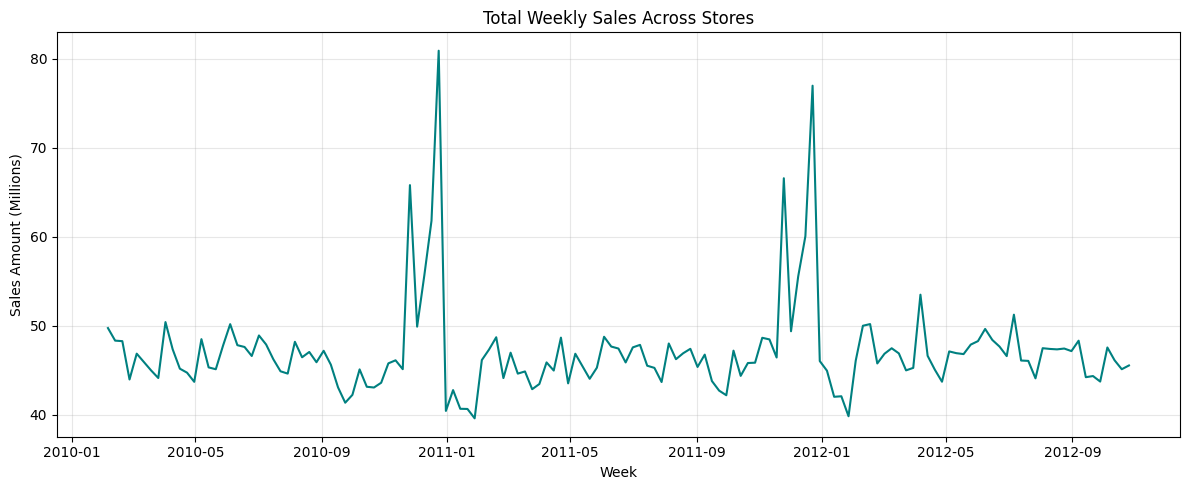

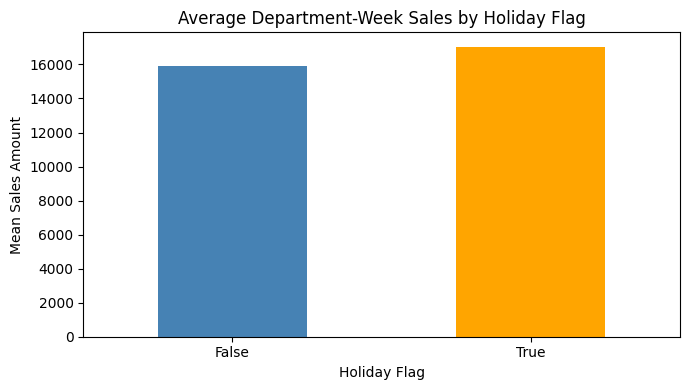

Both report charts saved.


In [ ]:
# Chart 1: Overall weekly sales.
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    weekly_sales.index,
    weekly_sales.values / 1_000_000,
    color="teal"
)

ax.set_title("Total Weekly Sales Across Stores")
ax.set_xlabel("Week")
ax.set_ylabel("Sales Amount (Millions)")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    output_folder / "overall_weekly_sales.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# Chart 2: Mean sales in holiday and non-holiday weeks.
fig, ax = plt.subplots(figsize=(7, 4))

holiday_summary["Mean_Sales"].plot(
    kind="bar",
    ax=ax,
    color=["steelblue", "orange"]
)

ax.set_title("Average Department-Week Sales by Holiday Flag")
ax.set_xlabel("Holiday Flag")
ax.set_ylabel("Mean Sales Amount")
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig(
    output_folder / "holiday_sales_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Both report charts saved.")

## Creating a Project Backup

We archive the project files currently available in Google Drive,
excluding existing ZIP archives.

The backup preserves the current work. It is not the final
submission: documentation links, repository publishing, and
the individual presentation still need to be completed.

In [ ]:
from zipfile import ZipFile, ZIP_DEFLATED

project_folder = data_folder.parent
backup_path = project_folder / "retail_project_backup.zip"

files_to_archive = [
    path
    for path in project_folder.rglob("*")
    if path.is_file() and path.suffix.lower() != ".zip"
]

notebook_files = [
    path for path in files_to_archive
    if path.suffix.lower() == ".ipynb"
]

with ZipFile(backup_path, "w", ZIP_DEFLATED) as archive:
    for path in files_to_archive:
        archive.write(
            path,
            arcname=str(path.relative_to(project_folder.parent))
        )

print("Files included:", len(files_to_archive))
print("Notebook files included:", len(notebook_files))
print(
    "Backup size (MB):",
    round(backup_path.stat().st_size / 1_000_000, 2)
)
print("Backup saved at:", backup_path)

if not notebook_files:
    print(
        "Notebook not found in this folder. Download it from "
        "Colab as .ipynb, upload it to the project folder, "
        "and rerun this backup cell."
    )

Files included: 39
Notebook files included: 1
Backup size (MB): 11.01
Backup saved at: /content/drive/MyDrive/Retail_Analytics_Project/retail_project_backup.zip


## Project Resources

- [GitHub Repository](https://github.com/Sachinsinghbaghel057/integrated-retail-analytics)
- [Detailed Project Report](https://docs.google.com/document/d/1DpD94rVaBdYI1wBZ_6hVlDMx491OFwn1HPQlISVvooY/edit?usp=sharing)